<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">ETUDE SUR LA FAIM DANS LE MONDE</h1>
</div>

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">I - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Analyse exploratoire du fichier population</h3>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> a) Chargement et description des tables</h4>
</div>

In [5]:
# Importation du fichier population.csv
pop = pd.read_csv("population.csv")

# Exclusion des informations de l'année 2018 car l'analyse porte sur la période 2013-2017
pop = pop.loc[pop["Année"] != 2018, :]

# Affichage des dimensions de la table population
pop.shape

(1180, 3)

In [152]:
# Affichage des caractéristiques de la table population
pop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1180 entries, 0 to 1414
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1180 non-null   object 
 1   Année   1180 non-null   int64  
 2   Valeur  1180 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 36.9+ KB


In [9]:
# Impression du nombre de modalités de la variable zone

print("La variable Zone est composée de",pop.groupby("Zone")["Zone"].count().shape[0], 
      "modalités correpondant aux différentes zones géographiques prises en compte dans l'étude.")

La variable Zone est composée de 236 modalités correpondant aux différentes zones géographiques prises en compte dans l'étude.


<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> b) Vérification de la complétude des données</h4>
</div>

Chaque zone est observée sur la période 2013 à 2017. Ducoup chaque zone est supposée avoir  5 observations annuelles.

In [11]:
# Identificaton des zones ayant moins de 5 observations annuelles

df = pop.groupby("Zone")["Année"].count()
df = df.reset_index()
print("Le nombre de zones ayant moins de cinq observations annuelles est de ", 
      df.loc[df["Année"] < 5, :].shape[0])

Le nombre de zones ayant moins de cinq observations annuelles est de  0


In [13]:
# Affichage des 5 premières lignes de la table
pop.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> c) Standardisation et renommage des variables</h4>
</div>

In [15]:
# Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
# Multiplication de la colonne valeur par 1000 pour avoir la taille de la population en unités 
pop["Valeur"] = pop["Valeur"] * 1000

# changement du nom de la colonne Valeur par Population
pop.rename(columns={"Valeur":"population", "Zone":"zone", "Année":"année"},
           inplace=True)

pop.loc[pop["zone"] == "République populaire démocratique de Corée", "zone"] = "Corée du nord"


# sauvegarde de la table au format csv
pop.to_csv("df_population.csv", index=False)


# Affichage des 5 premières lignes de la table pour voir les modifications
pop.head()

,zone,année,population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.3 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> a) Chargement et description des tables</h4>
</div>

In [17]:
# Importation du fichier dispo_alimentaire.csv
dispo_al = pd.read_csv("dispo_alimentaire.csv")

# Afficher les dimensions de la table sur la disponibilité alimentaire pour l'année 2017 
dispo_al.shape

(15605, 18)

In [164]:
# Caractéristique de la table disponibilité alimentaire
dispo_al.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15605 entries, 0 to 15604
Data columns (total 18 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Zone                                                           15605 non-null  object 
 1   Produit                                                        15605 non-null  object 
 2   Origine                                                        15605 non-null  object 
 3   Aliments pour animaux                                          2720 non-null   float64
 4   Autres Utilisations                                            5496 non-null   float64
 5   Disponibilité alimentaire (Kcal/personne/jour)                 14241 non-null  float64
 6   Disponibilité alimentaire en quantité (kg/personne/an)         14015 non-null  float64
 7   Disponibilité de matière grasse en quantité (g/personne/jo

In [165]:
# Affichage des 5 premieres lignes de la table
dispo_al.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> b) Vérification de la complétude des données</h4>
</div>

In [19]:
# Nombre de zones pour lesquelles on dispose des informations

print("On dispose des informations uniquement pour", dispo_al.groupby("Zone")["Zone"].count().shape[0], "zones sur un total de 236.", end="")

On dispose des informations uniquement pour 174 zones sur un total de 236.

In [21]:
# Construction de la liste des zones dont on ne dispose aucune informations sur les disponibilités alimentaires

# liste des zones de la table population 
liste_zone_pop = df["Zone"].unique().tolist()

# Liste des zones de la table dispo alimentaire
df2 = dispo_al.groupby("Zone")["Origine"].count()
df2 = df2.reset_index()
liste_zone_disp_al = df2["Zone"].unique().tolist()

# liste des zones dont on ne dispose aucune information sur la disponibilité alimentaire

liste_zone_non_dispo = []

for z in liste_zone_pop:
    if z not in liste_zone_disp_al:
        liste_zone_non_dispo.append(z)
print("Liste des zones dont on ne dispose aucune information sur les disponibilités alimentaires dans la table disponibilité alimentaire: ",
      liste_zone_non_dispo)


Liste des zones dont on ne dispose aucune information sur les disponibilités alimentaires dans la table disponibilité alimentaire:  ['Andorre', 'Anguilla', 'Antilles néerlandaises (ex)', 'Aruba', 'Bahreïn', 'Bhoutan', 'Bonaire, Saint-Eustache et Saba', 'Burundi', 'Comores', 'Curaçao', 'Gibraltar', 'Groenland', 'Guadeloupe', 'Guam', 'Guinée équatoriale', 'Guyane française', 'Libye', 'Liechtenstein', 'Martinique', 'Mayotte', 'Micronésie (États fédérés de)', 'Monaco', 'Montserrat', 'Nauru', 'Nioué', 'Palaos', 'Palestine', 'Papouasie-Nouvelle-Guinée', 'Porto Rico', 'Qatar', "Royaume-Uni de Grande-Bretagne et d'Irlande du Nord", 'République arabe syrienne', 'République démocratique du Congo', 'Réunion', 'Sahara occidental', 'Saint-Barthélemy', 'Saint-Marin', 'Saint-Martin (partie française)', 'Saint-Pierre-et-Miquelon', 'Saint-Siège', 'Sainte-Hélène, Ascension et Tristan da Cunha', 'Samoa américaines', 'Seychelles', 'Singapour', 'Sint Maarten  (partie néerlandaise)', 'Somalie', 'Soudan du S

Les informations sur la disponibilité alimentaire de ces zones ont été receullies dans le site de la FAO. Ainsi une table avec les disponbilités alimentaires de l'année 2017 dans ces zones a été construite

In [23]:
# Construction de la table sur les disponibilités alimentaires des zones su évoquées

# Chargement des tables et selection des variables necessaires
dispo_alim = pd.read_csv("FAOSTAT_data_fr_5-21-2025.csv")
dispo_alim = dispo_alim.drop(columns = ["Code Domaine", "Domaine", "Code année", "Code zone (M49)", "Code Produit (CPC)", "Année", "Symbole",
                           "Description du Symbole", "Note", "Code Élément"])

# Réorganisation de la table
dispo_alim_2 = dispo_alim.pivot_table(index=["Zone", "Produit", "Unité"],  columns=["Élément"], values="Valeur")
dispo_alim_2 = dispo_alim_2.reset_index()

In [25]:
# Impression de la table

dispo_alim_2.head()

Élément,Zone,Produit,Unité,Aliments pour animaux,Autres utilisations (non alimentaire),Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (g/personne/jour),Disponibilité alimentaire en quantité (tonnes),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Exportations - quantité,Importations - quantité,Loss,Production,Semences,Transformés,Variation de stock
0,Burundi,"Abats et foies comestibles d'oie, frais, réfri...",g/personne/jour,NaN,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Burundi,"Abats et foies comestibles d'oie, frais, réfri...",kcal/personne/jour,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Burundi,"Abats et foies comestibles d'oie, frais, réfri...",tonnes,NaN,NaN,NaN,NaN,0.04,NaN,NaN,NaN,0.04,NaN,NaN,NaN,NaN,NaN
3,Burundi,"Abats et foies comestibles de canard, frais, r...",g/personne/jour,NaN,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Burundi,"Abats et foies comestibles de canard, frais, r...",kcal/personne/jour,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
print("Cette nouvelle table contient jusqu'à ", len(dispo_alim_2["Produit"].unique().tolist()),
      "produits différents.", end = " ")
print("Alors que la table de disponibilité alimentaire initiale contient seulement", 
      len(dispo_al["Produit"].unique().tolist()), "produits.")


Cette nouvelle table contient jusqu'à  431 produits différents. Alors que la table de disponibilité alimentaire initiale contient seulement 98 produits.


In [29]:
# Produits de la table disponibilité alimentaire initiale 
print("Liste des produits de la table disonibilité alimentaire initiale : ",
      dispo_al["Produit"].unique().tolist())
print()
# Produits de la 2e table de disponibilité alimentaire
print("Liste des produits de la 2e table:", dispo_alim_2["Produit"].unique().tolist())

Liste des produits de la table disonibilité alimentaire initiale :  ['Abats Comestible', 'Agrumes, Autres', 'Aliments pour enfants', 'Ananas', 'Bananes', 'Beurre, Ghee', 'Bière', 'Blé', 'Boissons Alcooliques', 'Café', 'Coco (Incl Coprah)', 'Crème', 'Céréales, Autres', 'Dattes', 'Edulcorants Autres', 'Feve de Cacao', 'Fruits, Autres', 'Graines de coton', 'Graines de tournesol', 'Graisses Animales Crue', 'Huil Plantes Oleif Autr', 'Huile Graines de Coton', "Huile d'Arachide", "Huile d'Olive", 'Huile de Colza&Moutarde', 'Huile de Palme', 'Huile de Soja', 'Huile de Sésame', 'Huile de Tournesol', 'Lait - Excl Beurre', 'Légumes, Autres', 'Légumineuses Autres', 'Maïs', 'Miel', 'Millet', 'Miscellanees', 'Noix', 'Oeufs', 'Olives', 'Oranges, Mandarines', 'Orge', 'Plantes Oleiferes, Autre', 'Poissons Eau Douce', 'Poivre', 'Pommes', 'Pommes de Terre', 'Raisin', 'Riz (Eq Blanchi)', 'Sucre Eq Brut', 'Sucre, betterave', 'Sucre, canne', 'Sésame', 'Thé', 'Tomates', "Viande d'Ovins/Caprins", 'Viande de 

Il y'a donc eu un regroupement des produits dans la table de disponibilité alimentaire initiale. Ne sachant pas commment le regroupement a été effectué, il sera donc tres difficile de réaliser le meme regroupement dans la nouvelle table. Par conséquent  nous ne pouvons procéder à une complétude d'informations, à travers une jointure entre la nouvelle table de disponibiloité alimentaire  et l'ancienne. la suite de l'analyse s'effectuera donc avec la table de disponibilité alimentaire initiale dans laquelle des informations sur la disponibilité alimentaire dans certaines zones sont manquantes. 

In [31]:
# Calcul de la population mondiale de 2017 , en proportion de la poopulation totale, sur laquelle l'analyse sera effectuée
pop_mondiale = pop.groupby("année")["population"].sum()
pop_mondiale = pop_mondiale.reset_index()

# Population mondiale surlaquelle les informations sur la disponibilité alimentaire sont connues
pop_dispo_al = pop.loc[pop["zone"].isin(liste_zone_disp_al), :]
pop_dispo_al = pop_dispo_al.groupby("année")["population"].sum()
pop_dispo_al = pop_dispo_al.reset_index()

# Renommer les colonnes
pop_dispo_al.rename(columns = {"population":"pop-dispo_al"}, inplace=True)

# Création d'une table qui regroupe les deux types de population mondiale
pop_mond_dispo_al = pop_dispo_al
pop_mond_dispo_al["pop_mond_totale"] =  pop_mondiale["population"]


# Création des proportions des population 
pop_mond_dispo_al["prop_pop_disp_al"] =  round(pop_mond_dispo_al["pop-dispo_al"]/pop_mond_dispo_al["pop_mond_totale"]*100, 2)
pop_mond_dispo_al["prop_pop_non_disp_al"] = 100 - pop_mond_dispo_al["prop_pop_disp_al"]
pop_mond_dispo_al.head()

,année,pop-dispo_al,pop_mond_totale,prop_pop_disp_al,prop_pop_non_disp_al
0,2013,6.944803e+09,7.210846e+09,96.31,3.69
1,2014,7.025939e+09,7.295558e+09,96.30,3.70
2,2015,7.106663e+09,7.380067e+09,96.30,3.70
3,2016,7.186864e+09,7.464295e+09,96.28,3.72
4,2017,7.266471e+09,7.548134e+09,96.27,3.73


Les zones surlesquelles on ne dispose aucune informations sur les disponibilités alimentaires pour l'année 2017 représentent moins de 4% de la population mondiale. par conséquent ne pas tenir compte de ces zones n'aura tres fort probablement pas d'impact sur les résultats de nos analyses.

In [34]:
# Affichage des 5 premières lignes de la table

dispo_al.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> c) Standardisation et renommage des variables</h4>
</div>

In [38]:
# Création d'un dictionnaire des variables de la table disponibilité alimentaire

dict_variables = {"aliments": "Aliments pour animaux", "autres_ut":"Autres Utilisations", "dispo_alim_kcal": "Disponibilité alimentaire (Kcal/personne/jour)",
                  "dispo_alim_kg": "Disponibilité alimentaire en quantité (kg/personne/an)", "dispo_matiere_gr": "Disponibilité de matière grasse en quantité (g/personne/jour)",
                  "dispo_proteine": "Disponibilité de protéines en quantité (g/personne/jour)", "dispo_int":"Disponibilité intérieure = production  + importations + variation des stocks ",
                  "exportations": "Exportations - Quantité", "importations": "Importations - Quantité", "variation_stock" :"Variation de stock", "":""}


for i in dict_variables:
  print(i, ":", dict_variables[i])

aliments : Aliments pour animaux
autres_ut : Autres Utilisations
dispo_alim_kcal : Disponibilité alimentaire (Kcal/personne/jour)
dispo_alim_kg : Disponibilité alimentaire en quantité (kg/personne/an)
dispo_matiere_gr : Disponibilité de matière grasse en quantité (g/personne/jour)
dispo_proteine : Disponibilité de protéines en quantité (g/personne/jour)
dispo_int : Disponibilité intérieure = production  + importations + variation des stocks 
exportations : Exportations - Quantité
importations : Importations - Quantité
variation_stock : Variation de stock
 : 


In [40]:
# Définition d'une liste des noms des variables de la table disponibilité alimentaire
variables_dispo_al = dispo_al.columns.tolist()

# Remplacement des NaN dans le dataset par des 0
dispo_al[variables_dispo_al] = dispo_al[variables_dispo_al].fillna(0)

# Les quantités sont sont en milliers de tonnes. Pour un affichage facile sur les graphiques on les transforme en millions de tonnes 
# en divisant les quantités par 1000

dispo_al.iloc[:,  np.r_[3:5, 9:18]]  = dispo_al.iloc[:,  np.r_[3:5, 9:18]] / 1_000


# Renommer les variables
dispo_al.rename(columns={"Zone":"zone", "Produit": "produit", "Origine":"origine", "Aliments pour animaux":"aliments_animaux",
                         "Autres Utilisations":"autres_ut", "Disponibilité alimentaire (Kcal/personne/jour)":"dispo_alim_kcal",
                         "Disponibilité alimentaire en quantité (kg/personne/an)":"dispo_alim_kg",
                         "Disponibilité de matière grasse en quantité (g/personne/jour)":"dispo_matiere_gr",
                         "Disponibilité de protéines en quantité (g/personne/jour)":"dispo_proteine",
                         "Disponibilité intérieure": "dispo_int", "Exportations - Quantité":"exportations",
                         "Importations - Quantité": "importations", "Nourriture":"nourriture", "Pertes":"pertes", "Production":"production",
                         "Semences":"semences", "Traitement": "traitement",	"Variation de stock":"variation_stock"}, inplace=True)



dispo_al.loc[dispo_al["zone"] == "République populaire démocratique de Corée", "zone"] = "Corée du nord"

# sauvegarder la table au format csv
dispo_al.to_csv("df_disponibilite_alimentaire.csv", index=False)


# Affichage les 5 premières lignes de la table
dispo_al.head()

,zone,produit,origine,aliments_animaux,autres_ut,dispo_alim_kcal,dispo_alim_kg,dispo_matiere_gr,dispo_proteine,dispo_int,exportations,importations,nourriture,pertes,production,semences,traitement,variation_stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,0.053,0.000,0.000,0.053,0.000,0.053,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,0.041,0.002,0.040,0.039,0.002,0.003,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,0.002,0.000,0.002,0.002,0.000,0.000,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,0.082,0.000,0.082,0.082,0.000,0.000,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.4 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> a) Chargement et description des tables</h4>
</div>

In [42]:
# Importation du fichier sous_nutrition.csv
sous_nutrit = pd.read_csv("sous_nutrition.csv")

# Afficher les dimensions du dataset
sous_nutrit.shape

(1218, 3)

In [44]:
# Caractéristique de la table sous nutrition
sous_nutrit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Zone    1218 non-null   object
 1   Année   1218 non-null   object
 2   Valeur  624 non-null    object
dtypes: object(3)
memory usage: 28.7+ KB


In [46]:
# Afficher les dimensions de la table sur l'insécurité alimentaire
print("La table sur l'insécurité alimentaire comporte {} observations".format(sous_nutrit.shape[0]), end = "")
print(" et {} variables".format(sous_nutrit.shape[1]))

# Caractéristiques des variables de la table sur l'insécurité alimentaire
print("La variable zone comporte", sous_nutrit.groupby("Zone")["Zone"].count().shape[0], "modalités et ", end="")
print(sous_nutrit.groupby("Année")["Année"].count().shape[0], "modalités pour l'année. Chaque pays est observé sur 6 années.")

La table sur l'insécurité alimentaire comporte 1218 observations et 3 variables
La variable zone comporte 203 modalités et 6 modalités pour l'année. Chaque pays est observé sur 6 années.


In [48]:
# Liste des zones dont on ne dispose aucune informations sur la sous nutrition

# Liste des zones de la table sous nutrition
df_sous_nutr = sous_nutrit.groupby("Zone")["Année"].count()
df_sous_nutr2 = df_sous_nutr.reset_index()
liste_zone_sous_nutr = df_sous_nutr2["Zone"].unique().tolist()


# liste des zones dont on ne dispose aucune informations sur la disponibilité alimentaire
liste_zone_non_sous_nutr = []

for z in liste_zone_pop:
    if z not in df_sous_nutr:
        liste_zone_non_sous_nutr.append(z)

# Définition de la proportion de la population mondiale sur laquelle on ne dispose aucune infomration sur la sous nutrition

pop_non_sous_nutr = pop.loc[pop["zone"].isin(liste_zone_non_sous_nutr), :]
pop_non_sous_nutr = pop_non_sous_nutr.groupby("année")["population"].sum()
pop_non_sous_nutr = pop_non_sous_nutr.reset_index()
pop_non_sous_nutr.rename(columns = {"population":"pop-sous_nutr_non_dispo"}, inplace=True)

pop_mond_dispo_al["prop_pop_non_sous_nutr"] =  round(pop_non_sous_nutr["pop-sous_nutr_non_dispo"]/pop_mond_dispo_al["pop_mond_totale"]*100, 2)


In [50]:
print("Liste des zones  n'ayant aucune information sur l'insécurité alimentaire ", liste_zone_non_sous_nutr)
print("soit un total de : ", len(liste_zone_non_sous_nutr), "zones sur 236 représentant 0,06% de la population mondiale en 2017")

Liste des zones  n'ayant aucune information sur l'insécurité alimentaire  ['Anguilla', 'Antilles néerlandaises (ex)', 'Aruba', 'Bonaire, Saint-Eustache et Saba', 'Curaçao', 'Gibraltar', 'Guadeloupe', 'Guam', 'Guyane française', 'Liechtenstein', 'Martinique', 'Mayotte', 'Monaco', 'Montserrat', 'Réunion', 'Sahara occidental', 'Saint-Barthélemy', 'Saint-Marin', 'Saint-Martin (partie française)', 'Saint-Pierre-et-Miquelon', 'Saint-Siège', 'Sainte-Hélène, Ascension et Tristan da Cunha', 'Sint Maarten  (partie néerlandaise)', 'Île de Man', 'Îles Anglo-Normandes', 'Îles Caïmanes', 'Îles Falkland (Malvinas)', 'Îles Féroé', 'Îles Mariannes du Nord', 'Îles Turques-et-Caïques', 'Îles Vierges américaines', 'Îles Vierges britanniques', 'Îles Wallis-et-Futuna']
soit un total de :  33 zones sur 236 représentant 0,06% de la population mondiale en 2017


In [52]:
pop_mond_dispo_al.head()

,année,pop-dispo_al,pop_mond_totale,prop_pop_disp_al,prop_pop_non_disp_al,prop_pop_non_sous_nutr
0,2013,6.944803e+09,7.210846e+09,96.31,3.69,0.06
1,2014,7.025939e+09,7.295558e+09,96.30,3.70,0.06
2,2015,7.106663e+09,7.380067e+09,96.30,3.70,0.06
3,2016,7.186864e+09,7.464295e+09,96.28,3.72,0.06
4,2017,7.266471e+09,7.548134e+09,96.27,3.73,0.06


In [54]:
# Afficher les 5 premières lignes de la table

sous_nutrit.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> b) Standardisation et renommage des variables</h4>
</div>

In [56]:
# Conversion de la colonne valeur (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
sous_nutrit["Valeur"] = pd.to_numeric(sous_nutrit["Valeur"], errors="coerce")


# Puis remplacement des NaN en 0
sous_nutrit["Valeur"] = sous_nutrit["Valeur"].fillna(0)


# Renommage des variables
sous_nutrit.rename(columns={"Zone":"zone", "Année":"periode", "Valeur":"pop_sous_alim"}, inplace=True)



# Transformation des valeurs de la variables sur la population en unités
sous_nutrit["pop_sous_alim"] = sous_nutrit["pop_sous_alim"] * 1_000_000


# Définition d'une Liste des périodes
liste_periode = sous_nutrit["periode"].unique().tolist()


# Création de la variable année qui indique sur l'années de chaque période prise en compte
sous_nutrit["année"] = "2013"

a = 1
for pde in liste_periode:
    sous_nutrit.loc[sous_nutrit["periode"] == pde, "année"] = 2012 + a
    a += 1

# Exclusion des informations sur l'année 2018 car l'analyse porte sur la période 2013-2017
sous_nutrit = sous_nutrit[["zone", "periode", "année", "pop_sous_alim"]]
sous_nutrit = sous_nutrit.loc[sous_nutrit["année"] != 2018, :]



sous_nutrit.loc[sous_nutrit["zone"] == "République populaire démocratique de Corée", "zone"] = "Corée du nord"

# Sauvegarder la table au format csv
sous_nutrit.to_csv("df_sous_nutrition.csv", index=False)


# Actualisation du dictionnaire
dict_variables["pop_sous_alim"] = "Nombre de personne en état de sous nutrition"


# Afficher les 5 premières lignes de la table sous nutrition
sous_nutrit.head()

,zone,periode,année,pop_sous_alim
0,Afghanistan,2012-2014,2013,8600000.0
1,Afghanistan,2013-2015,2014,8800000.0
2,Afghanistan,2014-2016,2015,8900000.0
3,Afghanistan,2015-2017,2016,9700000.0
4,Afghanistan,2016-2018,2017,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.5 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> a) Chargement, description et renommage des variables</h4>
</div>

In [58]:
# Importation  de la table sur l'aide alimentaire
aide_al = pd.read_csv("aide_alimentaire.csv")

#Afficher les dimensions de la table
aide_al.shape

(1475, 4)

In [60]:
# Caractéristique de la table aide alimentaire
aide_al.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Pays bénéficiaire  1475 non-null   object
 1   Année              1475 non-null   int64 
 2   Produit            1475 non-null   object
 3   Valeur             1475 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.2+ KB


In [62]:
# Afficher les dimensions de la table sur l'aide alimentaire
print("La table sur l'aide alimentaire comporte {} observations".format(aide_al.shape[0]), end = "")
print(" et {} variables".format(aide_al.shape[1]))

# Caractéristiques des variables de la table disponibilité alimentaire
print("Les variables Année et valeur sont de type", aide_al["Année"].dtype, end="")
print(". Les variables Pays bénéficiaire et Produit sont de type", aide_al["Produit"].dtype, end = "")
print(". Avec", aide_al.groupby("Pays bénéficiaire")["Pays bénéficiaire"].count().shape[0], "modalités pour la variable Pays benficiaire", end="")
print(" et", aide_al.groupby("Produit")["Produit"].count().shape[0], "pour le Produit")


La table sur l'aide alimentaire comporte 1475 observations et 4 variables
Les variables Année et valeur sont de type int64. Les variables Pays bénéficiaire et Produit sont de type object. Avec 76 modalités pour la variable Pays benficiaire et 16 pour le Produit


In [64]:
# Renommer les variables
aide_al.rename(columns={"Pays bénéficiaire":"zone", "Année":"année", "Produit":"produit", "Valeur":"quantité"}, inplace=True)


# Transformation des quantités d'aide alimentaire des tonnes en KG
#aide_al["quantité"]  = aide_al["quantité"] * 1_000


# Exclusion des informations sur 2018
aide_al = aide_al.loc[aide_al["année"] != 2018, :]


aide_al.loc[aide_al["zone"] == "République populaire démocratique de Corée", "zone"] = "Corée du nord"

# Sauvegarder la table au format csv
aide_al.to_csv("df_aide_alimentaire.csv", index=False)


# Affichage les 5 premières lignes de la table
aide_al.head()


,zone,année,produit,quantité
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">II - Construction des indicateurs et analyse approfondie des données</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Définition des fonctions pour afficher les graphiques</h3>
</div>

In [66]:

# Définition de fonction pour afficher les diagrammes à barres 

def plot_countries_by_level_indicator(data_frame: pd.DataFrame, 
                                          column_name: str = "nourriture", 
                                          n_countries: int = 10,
                                          y_axis_limits: int = 100,
                                          order: str = "head",
                                          ylabel: str = "show a label",
                                          title: str = "bar",
                                          fig_dimension: tuple = (12, 6)) -> None:
    """
    Plot a bar chart of the top countries by food allocation percentage.
    
    Args:
        data_frame (pd.DataFrame): DataFrame containing the food allocation data
        column_name (str): Column name for food allocation values
        n_countries (int): Number of top countries to display
        
    Returns:
        None: Displays the plot
    """
    
    # Get top countries by food allocation
    if order == "head":
        order_data = data_frame.sort_values(column_name, ascending=False).head(n_countries)
    elif order == "tail":
        order_data = data_frame.sort_values(column_name, ascending=False).tail(n_countries)
    
    # Create the plot
    plt.figure(figsize=fig_dimension)
    plt.bar(height=order_data[column_name], x=order_data["zone"])
    
    # Set y-axis limits
    
    plt.ylim(0, y_axis_limits)
    
    # Add title and labels
    plt.title(title, color="green", fontweight="bold", fontname="Arial", fontsize=12)
    plt.xlabel("Pays", fontweight="bold")
    plt.ylabel(ylabel, fontweight="bold")
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels on top of each bar
    values = order_data[column_name].tolist()
    for i, value in enumerate(values):
        plt.text(i-0.3, value+1, round(value))
    
    plt.show()

In [97]:

# Définition d'une fonction pour catégoriser le niveau de prévalence de sous nutrition dans chaque zone

def categorize_malnutrition(df: pd.DataFrame) -> pd.DataFrame:
    """
    Categorizes zones based on their malnutrition rates.
    
    Args:
        df (pd.DataFrame): DataFrame containing malnutrition data with 'zone' and 'prop_pop_sous_al' columns
        
    Returns:
        pd.DataFrame: DataFrame with added categorization columns 'prev_sous_nutr' and 'prev_sous_nutr_2'
    """
    # Define categorization thresholds and labels
    categories = [
        (0, 0, "Pas de sous nutrition", "Pas de sous nutrition"),
        (0, 5, "Moins de 5%", "Tres faible"),
        (5, 10, "5 - 10%", "Faible"),
        (10, 20, "10 - 20%", "Modéré"),
        (20, 30, "20 - 30%", "Elevé"),
        (30, float('inf'), "Plus de 30%", "Tres élevé")
    ]
    
    # Create a copy to avoid modifying the original dataframe
    result_df = df.copy()
    
    # Apply categorization for each unique zone
    for zone in result_df["zone"].unique():
        # Get the malnutrition rate for this zone
        mal_rate = result_df.loc[result_df["zone"] == zone, "prop_pop_sous_al"].values[0]
        
        # Find the appropriate category
        for lower, upper, label1, label2 in categories:
            if lower <= mal_rate <= upper:
                result_df.loc[result_df["zone"] == zone, "prev_sous_nutr"] = label1
                result_df.loc[result_df["zone"] == zone, "prev_sous_nutr_2"] = label2
                break
    
    return result_df



In [99]:
# Définition d'une fonction qui affiche la proportion du type de produit

def plot_pie_chart(
    data: pd.DataFrame, 
    category_column: str,
    title: str = "Pie Chart",
    figsize: tuple = (13, 6),
    colors: list = None,
    **kwargs
) -> None:
    """
    Creates a pie chart showing the proportions of categories in a DataFrame column.
    
    Args:
        data (pd.DataFrame): DataFrame containing the data to plot
        category_column (str): Name of the column to use for categories
        title (str, optional): Title for the pie chart. Defaults to "Pie Chart".
        figsize (tuple, optional): Figure size as (width, height). Defaults to (13, 6).
        colors (list, optional): List of colors for pie slices. Defaults to None.
        **kwargs: Additional keyword arguments to pass to plt.pie()
    
    Returns:
        None: This function displays a plot but doesn't return any value.
        
    Raises:
        KeyError: If the specified category_column doesn't exist in the DataFrame
    """
    if category_column not in data.columns:
        raise KeyError(f"Column '{category_column}' not found in DataFrame")
    
    # Count occurrences of each category
    value_counts = data[category_column].value_counts()
    
    plt.figure(figsize=figsize)
    plt.pie(
        x=value_counts.values,
        labels=value_counts.index,
        autopct='%.1f%%',
        colors=colors,
        **kwargs
    )
    plt.title(title, color="green", fontweight="bold", fontname="Arial", fontsize=12)
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Calcul des indicateurs de sous alimentation</h3>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> a) Construction de la table appropriée</h4>
</div>

In [101]:
# Chargement des tables
df_pop = pd.read_csv("df_population.csv")
df_sous_nutrit = pd.read_csv("df_sous_nutrition.csv")


# Jointure des tables population et sous nutrtion 
df_sous_nutrition = pd.merge(df_sous_nutrit, df_pop, on = ["zone", "année"], how="left")


# description de la table
df_sous_nutrition.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   zone           1015 non-null   object 
 1   periode        1015 non-null   object 
 2   année          1015 non-null   int64  
 3   pop_sous_alim  1015 non-null   float64
 4   population     1015 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 39.8+ KB


Pour vérifier si les données sont completes, on va identifier les pays qui ont moins de 5 années d'observation, car chaque pays est observé sur 5 ans. De 2013 à 2017

In [104]:
# Nombre de pays ayant moins de 5 années d'observation. 
verif_tab = df_sous_nutrition.groupby("zone")["année"].count().reset_index()

print("Le nombre de pays ayant moins de 5 ans d'observation est de", verif_tab.loc[verif_tab["année"] < 5, :].shape[0], ". Les données sont donc complètes")


Le nombre de pays ayant moins de 5 ans d'observation est de 0 . Les données sont donc complètes


In [106]:
# Affichage du nouveau dataset
df_sous_nutrition.head()

,zone,periode,année,pop_sous_alim,population
0,Afghanistan,2012-2014,2013,8600000.0,32269589.0
1,Afghanistan,2013-2015,2014,8800000.0,33370794.0
2,Afghanistan,2014-2016,2015,8900000.0,34413603.0
3,Afghanistan,2015-2017,2016,9700000.0,35383032.0
4,Afghanistan,2016-2018,2017,10500000.0,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> b) Construction des indicateurs</h4>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h5 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> i) Nombre de personnes en sous alimentation</h5>
</div>

In [110]:
# Nombre de personnes en sous alimentation dans le monde sur la période 2013-2017
sous_al_ann = df_sous_nutrition.groupby("année")["pop_sous_alim"].sum().reset_index()
sous_al_ann.sort_values("pop_sous_alim", ascending=False)


# Mettre la variable sur le nombre de personne sous alimentée en millions
sous_al_ann["pop_sous_alim_2"] = round(sous_al_ann["pop_sous_alim"] / 1_000_000)

([<matplotlib.axis.XTick at 0x1c22f552600>,
 [Text(2013, 0, '2013'),
  Text(2014, 0, '2014'),
  Text(2015, 0, '2015'),
  Text(2016, 0, '2016'),
  Text(2017, 0, '2017')])

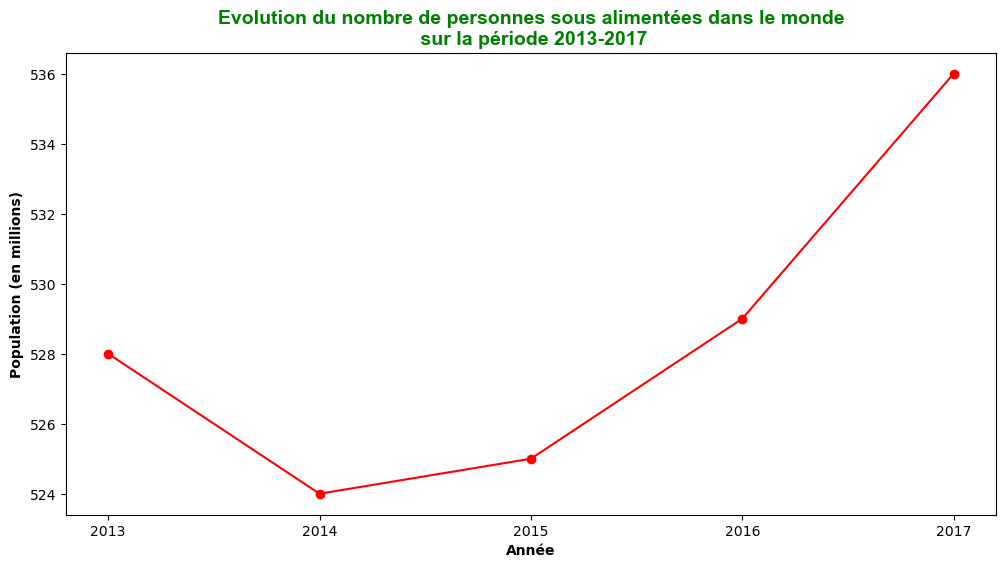

In [112]:
# Affichage de l'évolution du nombre de personne en sous alimentation dans le monde
plt.figure(figsize=(12,6))
plt.plot(sous_al_ann["année"], sous_al_ann["pop_sous_alim_2"], marker='o', color='red')
plt.title("Evolution du nombre de personnes sous alimentées dans le monde\n sur la période 2013-2017",
          color="green", fontweight="bold", fontname="Arial", fontsize=14)
plt.xlabel("Année", fontweight ="bold")
plt.ylabel("Population (en millions)", fontweight ="bold")
plt.xticks([2013, 2014, 2015, 2016, 2017])

<div style="border: 1px solid RGB(0,150,250);" >
<h5 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> ii) Proportion de la population mondiale en état de sous alimentation sur la période 2013-2017</h5>
</div>

In [115]:
# Calcul de la proportion de personnes en sous alimentation dans chaque pays chaque année
df_sous_nutrition["prop_pop_sous_al"] = round((df_sous_nutrition["pop_sous_alim"] / df_sous_nutrition["population"])*100, 2)


# Sauvegarder la table au format csv
df_sous_nutrition.to_csv("df_sous_nutrition_2.csv", index=False)


In [117]:
# Calcul de la proportion de la population mondiale sous alimentée

# méthode 1
sous_al_prop_mon_1 = df_sous_nutrition.groupby("année")["prop_pop_sous_al"].mean().reset_index()


# méthode 2
# calcul de la population mondiale totale et et la population mondiale sous alimentée chaque année
pop_mon_sous_al = df_sous_nutrition.groupby("année")["pop_sous_alim"].sum().reset_index()
pop_mon_tot = df_sous_nutrition.groupby("année")["population"].sum().reset_index()

# jointure des deux populations 
sous_al_prop_mon_2 = pd.merge(pop_mon_tot, pop_mon_sous_al, on ="année")

# Calcul de la proportion de la population
sous_al_prop_mon_2["prop_pop_sous_al"] = round((sous_al_prop_mon_2["pop_sous_alim"] / sous_al_prop_mon_2["population"])*100, 2)


([<matplotlib.axis.XTick at 0x1c22f565490>,
 [Text(2013, 0, '2013'),
  Text(2014, 0, '2014'),
  Text(2015, 0, '2015'),
  Text(2016, 0, '2016'),
  Text(2017, 0, '2017')])

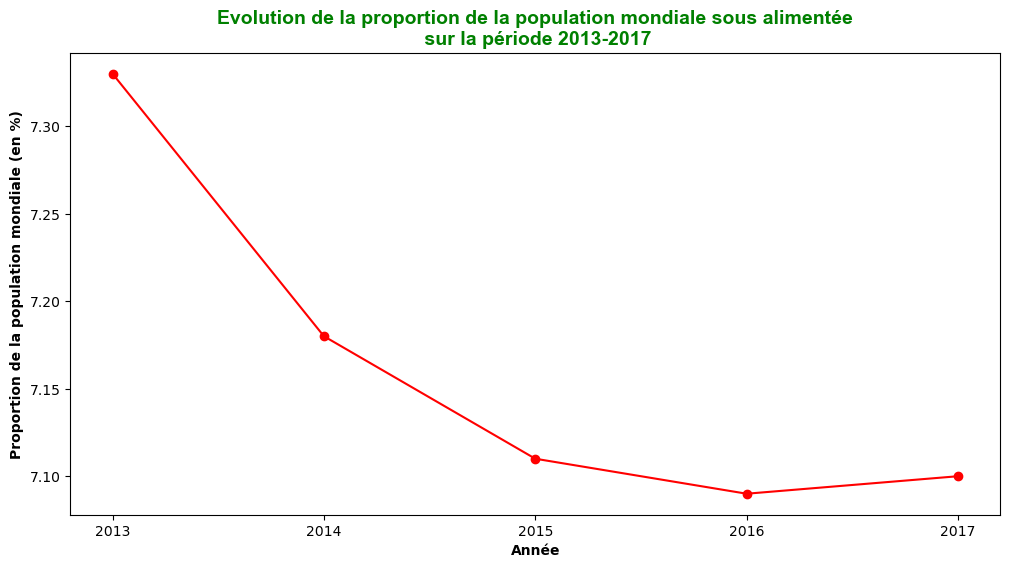

In [119]:

# Evolution de la proportion de la population mondiale en sous alimentation sur la période 2013-2017
plt.figure(figsize=(12,6))
plt.plot(sous_al_prop_mon_2["année"], sous_al_prop_mon_2["prop_pop_sous_al"], marker='o', color='red')
plt.title("Evolution de la proportion de la population mondiale sous alimentée\n sur la période 2013-2017",
          color="green", fontweight="bold", fontname="Arial", fontsize=14)
plt.xlabel("Année", fontweight ="bold")
plt.ylabel("Proportion de la population mondiale (en %)", fontweight ="bold")
plt.xticks([2013, 2014, 2015, 2016, 2017])


([<matplotlib.axis.XTick at 0x1c22f55d9a0>,
 [Text(2013, 0, '2013'),
  Text(2014, 0, '2014'),
  Text(2015, 0, '2015'),
  Text(2016, 0, '2016'),
  Text(2017, 0, '2017')])

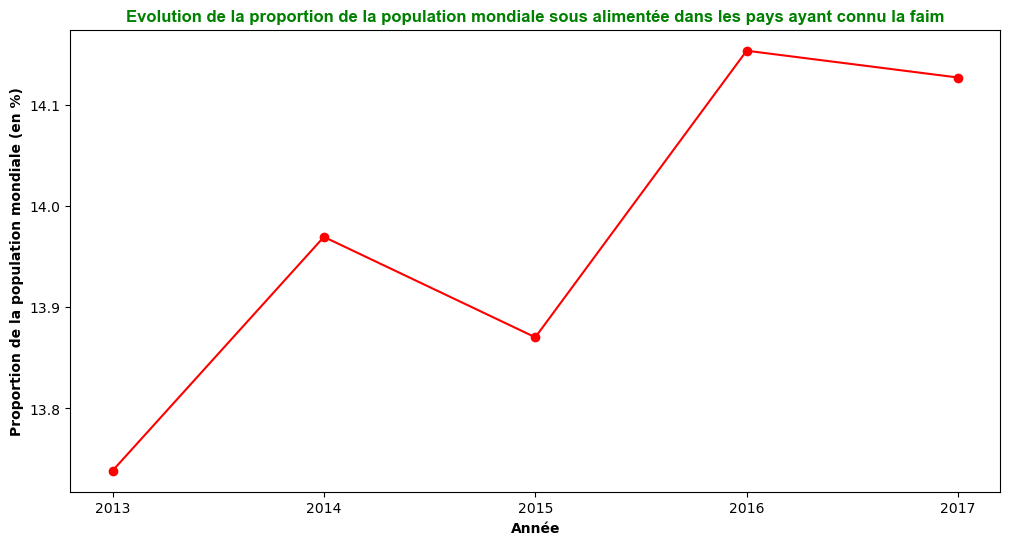

In [121]:
# Proportion de la population mondiale sous alimentée chaque année en excluant les zones qui n'ont jamais connu la faim

# Exclusion des zones du monde qui n'ont jamais connu la faim sur la période 2013-2017
df_sous_nutrt = df_sous_nutrition.loc[df_sous_nutrition["prop_pop_sous_al"] != 0, :]

sous_al_prop_mon = df_sous_nutrt.groupby("année")["prop_pop_sous_al"].mean().reset_index()

sous_al_prop_mon
# Evolution de la proportion de la population mondiale en sous alimentation sur la période 2013-2017

plt.figure(figsize=(12,6))
plt.plot(sous_al_prop_mon["année"], sous_al_prop_mon["prop_pop_sous_al"], marker='o', color='red')
plt.title("Evolution de la proportion de la population mondiale sous alimentée dans les pays ayant connu la faim",
          color="green", fontweight="bold", fontname="Arial", fontsize=12)
plt.xlabel("Année", fontweight ="bold")
plt.ylabel("Proportion de la population mondiale (en %)", fontweight ="bold")
plt.xticks([2013, 2014, 2015, 2016, 2017])


In [123]:
# calcul du niveau de prévalence de sous nutrition en 2017 dans chaque zone
sous_al_pays_17 = df_sous_nutrition.loc[df_sous_nutrition["année"] == 2017, : ] 

# Calcul du niveau de prévalence de sous nutrition moyen sur la période 2013-2017 dans chaque zone
sous_al_pays = df_sous_nutrition.groupby("zone")["prop_pop_sous_al"].mean().reset_index()


In [125]:
sous_al_pays.head()

,zone,prop_pop_sous_al
0,Afghanistan,27.044
1,Afrique du Sud,4.904
2,Albanie,3.456
3,Algérie,3.274
4,Allemagne,0.000


In [127]:
# Nombre de pays en situation de sous nutrition, en fonction du niveau de prévalence moyen de la sous nutrition sur la période 2013-2017

# La fonction categorize_malnutrition catégorise les niveaux de prevalence de sous nutrtion dans chaque zone
sous_al_pays_2 = categorize_malnutrition(sous_al_pays)


# Comptage du nombre de pays dans chaque niveau de prévalence
nb_pays_sous_nutrt = sous_al_pays_2.groupby(["prev_sous_nutr", "prev_sous_nutr_2"]).size().reset_index(name="nombre_de_pays")



# Ordonner les modaliés du niveau de sous nutrition
ordre_niv_sous_nutr = ["Pas de sous nutrition", "Moins de 5%", "5 - 10%", "10 - 20%", "20 - 30%", "Plus de 30%"] 
nb_pays_sous_nutrt["prev_sous_nutr"] = pd.Categorical(nb_pays_sous_nutrt["prev_sous_nutr"], categories=ordre_niv_sous_nutr, ordered=True)
nb_pays_sous_nutrt = nb_pays_sous_nutrt.sort_values("prev_sous_nutr")

# Affichage du dataset
nb_pays_sous_nutrt.head()

,prev_sous_nutr,prev_sous_nutr_2,nombre_de_pays
4,Pas de sous nutrition,Pas de sous nutrition,117
3,Moins de 5%,Tres faible,20
2,5 - 10%,Faible,22
0,10 - 20%,Modéré,25
1,20 - 30%,Elevé,11


In [129]:
# Nombre de pays en situation de sous alimentation en 2017, selon  niveau de prévalence de sous alimentation 

sous_al_pays_17_2 = categorize_malnutrition(sous_al_pays_17)
nb_pays_sous_nutrt_17 = sous_al_pays_17_2.groupby(["prev_sous_nutr", "prev_sous_nutr_2"]).size().reset_index(name="nombre_de_pays")



# Ordonner les modaliés du niveau de sous nutrition
nb_pays_sous_nutrt_17["prev_sous_nutr"] = pd.Categorical(nb_pays_sous_nutrt_17["prev_sous_nutr"], categories=ordre_niv_sous_nutr, ordered=True)
nb_pays_sous_nutrt_17 = nb_pays_sous_nutrt_17.sort_values("prev_sous_nutr")


nb_pays_sous_nutrt_17.head()

,prev_sous_nutr,prev_sous_nutr_2,nombre_de_pays
4,Pas de sous nutrition,Pas de sous nutrition,119
3,Moins de 5%,Tres faible,17
2,5 - 10%,Faible,25
0,10 - 20%,Modéré,23
1,20 - 30%,Elevé,10


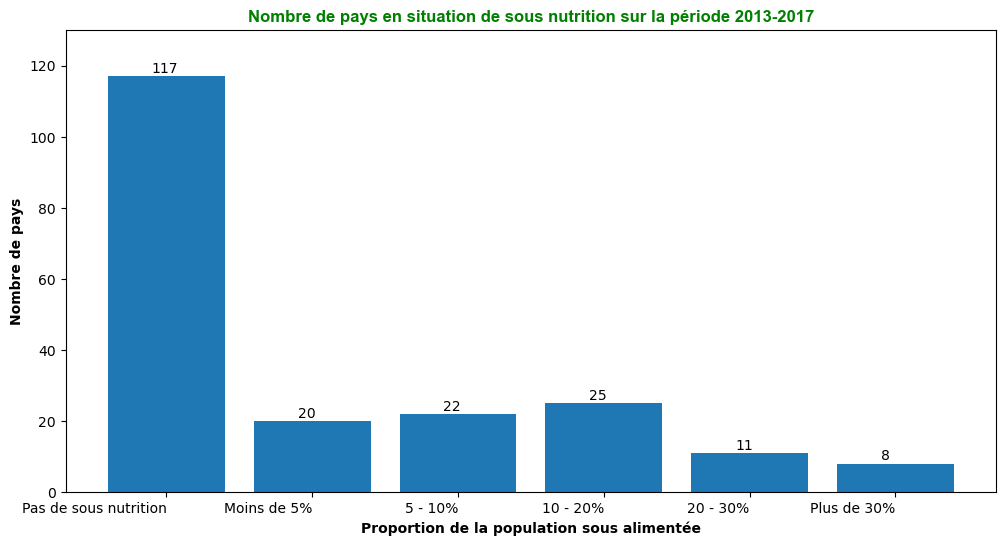

In [131]:
# Affichage du nombre de pays en situation de sous alimentation sur la période 2013-2017, en fonction du niveau de prévalence de sous nutrition

plt.figure(figsize=(12,6))
plt.bar(height=nb_pays_sous_nutrt["nombre_de_pays"], x=nb_pays_sous_nutrt["prev_sous_nutr"])
plt.ylim(0, 130) # Pour préciser l'étendu des valeurs de l'axes des ordonnées

plt.title("Nombre de pays en situation de sous nutrition sur la période 2013-2017",
          color="green", fontweight="bold", fontname="Arial", fontsize=12)
plt.xlabel("Proportion de la population sous alimentée", fontweight ="bold")
plt.ylabel("Nombre de pays", fontweight ="bold")
plt.xticks(rotation=0, ha='right')  # ha='right' = alignement à droite


# Afficher les valeurs associées à chaque niveau 

val_niv = nb_pays_sous_nutrt["nombre_de_pays"].tolist()
for i in range(6):
    plt.text(i-0.1, val_niv[i]+1, round(val_niv[i]))
plt.show()

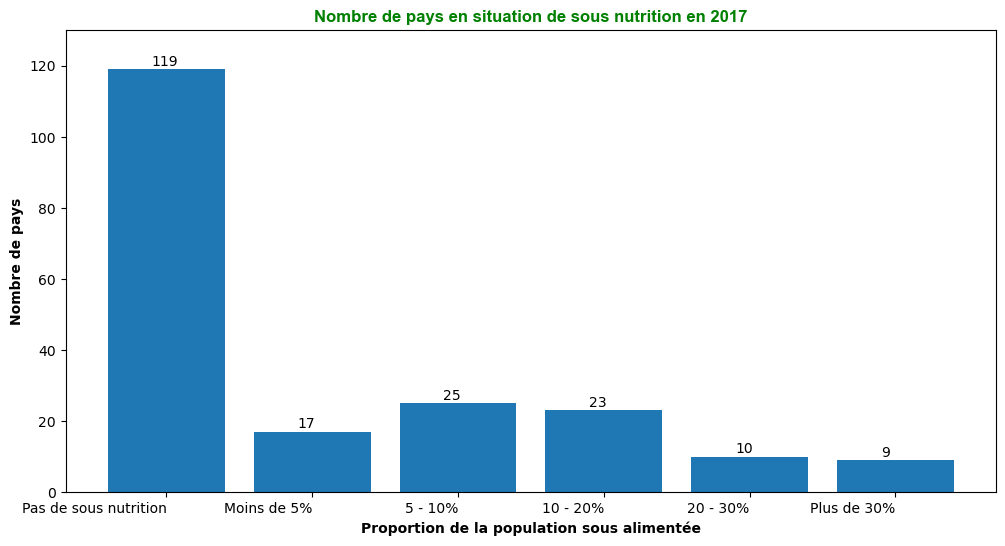

In [133]:
# Affichage du nombre de pays en situation de sous alimentation en 2017, en fonction du niveau de prévalence de sous nutrition

plt.figure(figsize=(12,6))
plt.bar(height=nb_pays_sous_nutrt_17["nombre_de_pays"], x=nb_pays_sous_nutrt_17["prev_sous_nutr"])
plt.ylim(0, 130) # Pour préciser l'étendu des valeurs de l'axes des ordonnées

plt.title("Nombre de pays en situation de sous nutrition en 2017",
          color="green", fontweight="bold", fontname="Arial", fontsize=12)
plt.xlabel("Proportion de la population sous alimentée", fontweight ="bold")
plt.ylabel("Nombre de pays", fontweight ="bold")
plt.xticks(rotation=0, ha='right')  # ha='right' = alignement à droite


# Afficher les valeurs associées à chaque niveau 

val_niv = nb_pays_sous_nutrt_17["nombre_de_pays"].tolist()
for i in range(6):
    plt.text(i-0.1, val_niv[i]+1, round(val_niv[i]))
plt.show()

In [135]:
# Top 10 des pays les plus affamés dans le monde sur la période 2013-2017, selon la proportion de la population affamée

sous_al_prop_mon_3 = df_sous_nutrt.groupby("zone")["prop_pop_sous_al"].mean().reset_index()

top_pays_sous_al = sous_al_prop_mon_3.sort_values("prop_pop_sous_al", ascending=False).head(10)

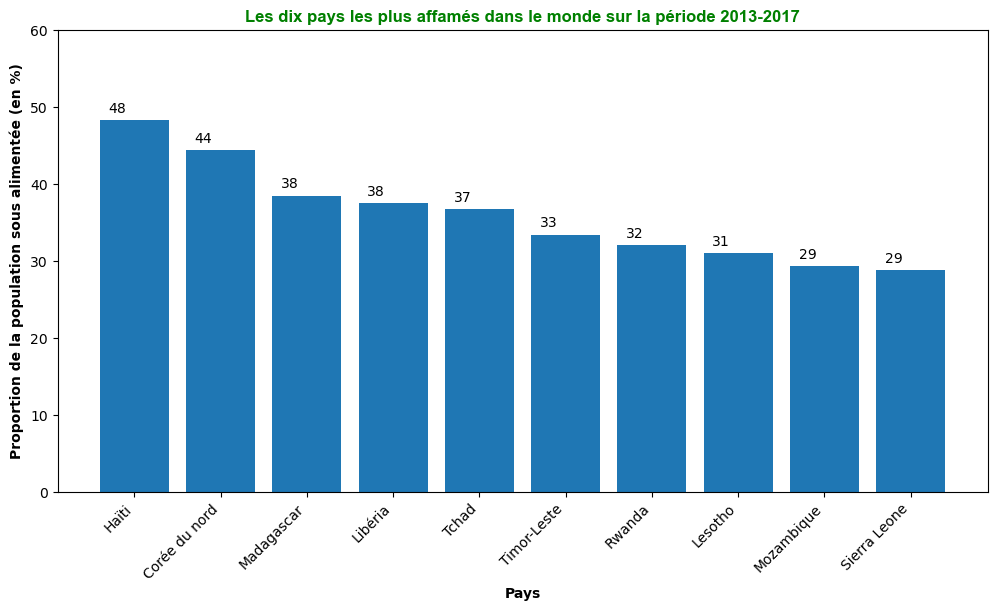

In [137]:
# Affichage des 10 pays les plus affamés

plot_countries_by_level_indicator(data_frame=top_pays_sous_al, 
                                          column_name="prop_pop_sous_al", 
                                          n_countries=10,
                                          y_axis_limits=60,
                                          order="head",
                                          ylabel="Proportion de la population sous alimentée (en %)",
                                          title="Les dix pays les plus affamés dans le monde sur la période 2013-2017")

In [139]:
# Top 10 des pays les plus affamés dans le monde  en 2017, selon la proportion de la population affamée

sous_al_prop_mon_3_17 = df_sous_nutrt.loc[df_sous_nutrt["année"] == 2017, :]

top_pays_sous_al_17 = sous_al_prop_mon_3_17.sort_values("prop_pop_sous_al", ascending=False).head(10)

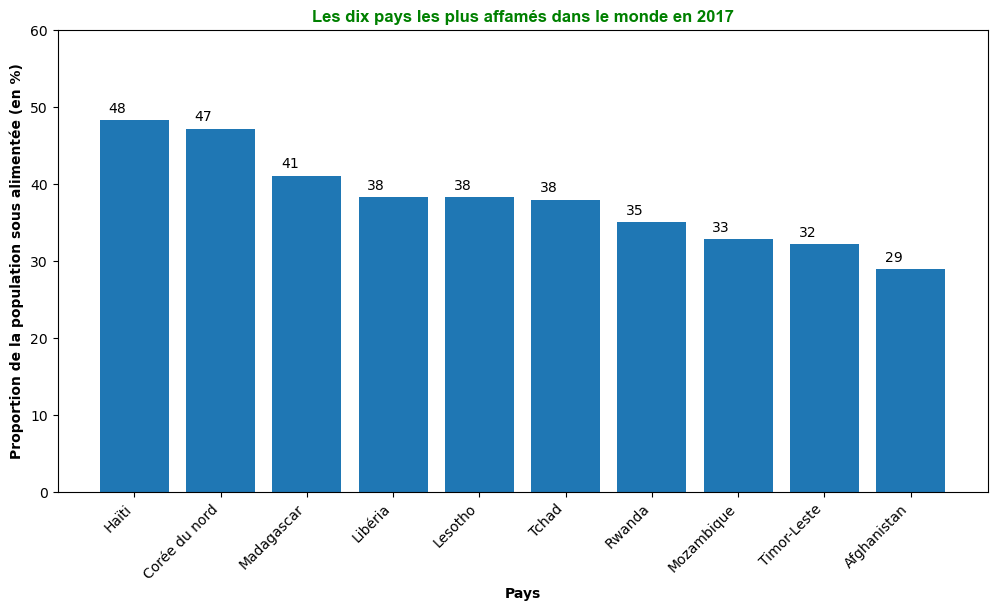

In [141]:
# Affichage des résultats

plot_countries_by_level_indicator(data_frame=top_pays_sous_al_17, 
                                          column_name="prop_pop_sous_al", 
                                          n_countries=10,
                                          y_axis_limits=60,
                                          order="head",
                                          ylabel="Proportion de la population sous alimentée (en %)",
                                          title="Les dix pays les plus affamés dans le monde en 2017")

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Calcul de la capacité alimentaire</h3>
</div>

In [144]:
# Chargement de la table disponibilité alimentaire
df_dispo_al = pd.read_csv("df_disponibilite_alimentaire.csv")

# Calcul de la disponibilité alimentaire totale en kcal par jour  et  en fonction de l'origine des produits dans chaque pays 
dispo_alim_zone = df_dispo_al[["zone", "origine", "dispo_alim_kcal"]].pivot_table(
    index="zone", columns="origine", values="dispo_alim_kcal", aggfunc="sum")


dispo_alim_zone = dispo_alim_zone.reset_index()
dispo_alim_zone.rename(columns={"animale":"dispo_al_animal", "vegetale":"dispo_al_vegetale"}, inplace=True)


# Calcul de la disponibilité alimentaire totale
dispo_alim_zone["dispo_al_totale"] = dispo_alim_zone["dispo_al_animal"] + dispo_alim_zone["dispo_al_vegetale"]


# Jointure avec la table population
df_pop = pd.read_csv("df_population.csv")
df_pop_17 = df_pop.loc[df_pop["année"] == 2017, ["zone", "population"]]
dispo_alim_zone_17 = pd.merge(dispo_alim_zone , df_pop_17, on ="zone", how="left")

# dict_variables

# Affichage de la table
dispo_alim_zone_17.head()

,zone,dispo_al_animal,dispo_al_vegetale,dispo_al_totale,population
0,Afghanistan,216.0,1871.0,2087.0,36296113.0
1,Afrique du Sud,487.0,2533.0,3020.0,57009756.0
2,Albanie,985.0,2203.0,3188.0,2884169.0
3,Algérie,378.0,2915.0,3293.0,41389189.0
4,Allemagne,1042.0,2461.0,3503.0,82658409.0


<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> a) - Estimation du nombre de personnes pouvant etre nourries</h4>
</div>

Selon les organisations onusienne (FAO, PAM) en charge des questions alimetaires dans le monde, il faudra en moyenne 2100 kcal/jour/ à une personne pour son alimentation.

Le nombre de personne pouvant théoriquement etre nourrie est égale au rapport entre la disponibilité alimentaire totale pour l'ensemble des individus et le nombre de Kcal necessaire pour une bonne alimentation. 

In [148]:
dispo_alim_zone_17[["dispo_al_animal", "dispo_al_vegetale"]].sum()

dispo_al_animal       96660.0
dispo_al_vegetale    398782.0
dtype: float64

In [150]:
# Calcul du nombre de personnes pouvant etre nourri dans chaque pays en 2017

dispo_alim_zone_17["nb_pers_nourrie"] = round(dispo_alim_zone_17["dispo_al_totale"] *  dispo_alim_zone_17["population"] / 2100)

In [152]:
print("En 2017 la population mondiale était de ", dispo_alim_zone_17["population"].sum(), "personnes.")
print("Les disponibilités alimentaires cette année permettaient de nourrir au total", dispo_alim_zone_17["nb_pers_nourrie"].sum(), "personnes.")
print("soit ", round(dispo_alim_zone_17["nb_pers_nourrie"].sum() / dispo_alim_zone_17["population"].sum(), 2), "fois plus de personnes pouvant etre nourrie.")
  

En 2017 la population mondiale était de  7291900830.0 personnes.
Les disponibilités alimentaires cette année permettaient de nourrir au total 9961421245.0 personnes.
soit  1.37 fois plus de personnes pouvant etre nourrie.


Les disponibilités alimentaires mondiales de 2017 permettait donc, non seulement de couvrir les besoins alimentaires mondiaux,
mais aussi de nourrir en plus  37% de la population mondiale. 

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> b) - Estimation du nombre de personnes pouvant etre nourries avec les produits végétaux</h4>
</div>

In [156]:
# Calcul du nombre de personne pouvant etre nourrie en 2017 uniquement par des produits végétaux
dispo_alim_zone_17["nb_pers_nour_veg"] = round(dispo_alim_zone_17["dispo_al_vegetale"] *  dispo_alim_zone_17["population"] / 2100)

In [158]:

print("Lorsqu'on considére uniquement les produits d'origine végétale, on pourrait nourrir", round(dispo_alim_zone_17["nb_pers_nour_veg"].sum() / dispo_alim_zone_17["population"].sum(), 2), "fois plus de personnes.")
print("Soit au total", dispo_alim_zone_17["nb_pers_nour_veg"].sum(), "personnes.")

Lorsqu'on considére uniquement les produits d'origine végétale, on pourrait nourrir 1.13 fois plus de personnes.
Soit au total 8219411527.0 personnes.


Meme lorsqu'on considere uniquement les produits alimentaires, les disponibilitées alimentaires de 2017 permettaient de nourrir
13% de la population mondiale en plus. 

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> c) - Disponibilité alimentaire par personne selon le pays</h4>
</div>

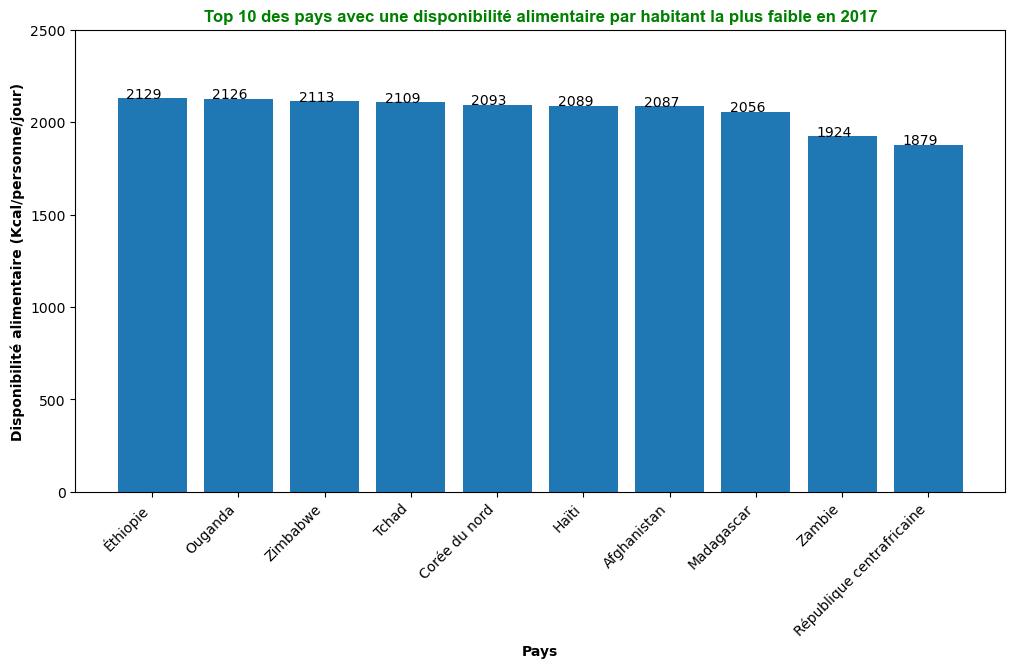

In [162]:
# Affichage des 10 pays qui ont le moins de disponibilité alimentaire par personne 

plot_countries_by_level_indicator(data_frame=dispo_alim_zone, 
                                          column_name="dispo_al_totale", 
                                          n_countries=10,
                                          y_axis_limits=2500,
                                          order="tail",
                                          ylabel="Disponibilité alimentaire (Kcal/personne/jour)",
                                          title="Top 10 des pays avec une disponibilité alimentaire par habitant la plus faible en 2017")


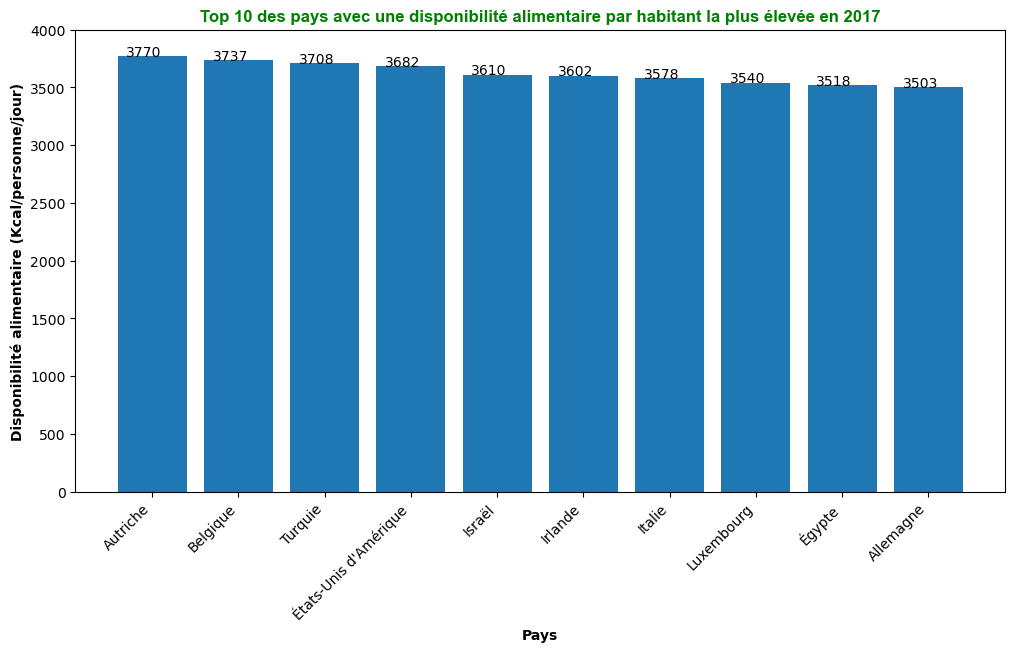

In [164]:
# Affichage des 10 pays qui ont le plus de disponibilité alimentaire par personne 

plot_countries_by_level_indicator(data_frame=dispo_alim_zone, 
                                          column_name="dispo_al_totale", 
                                          n_countries=10,
                                          y_axis_limits=4000,
                                          order="head",
                                          ylabel="Disponibilité alimentaire (Kcal/personne/jour)",
                                          title="Top 10 des pays avec une disponibilité alimentaire par habitant la plus élevée en 2017")


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.4 - Analyse de la disponibilité alimentaire intérieure</h3>
</div>

In [167]:
# Chargement de la table disponibilité alimentaire
df_dispo_al = pd.read_csv("df_disponibilite_alimentaire.csv")


# Définition de la liste des variables à aggréger

variables_aggr = ["dispo_int", "aliments_animaux", "nourriture", "pertes",
                  "autres_ut", "exportations", "importations", "production",
                  "semences", "traitement","variation_stock"]

dispo_alimentaire = df_dispo_al.groupby("zone")[variables_aggr].sum().reset_index()


In [169]:
# Calcul de la disponibilité totale /  disponibilités totales =  Production + importations + baisses des stocks
# Toutes les quantités sont en millions de tonnes
dispo_alimentaire["dispo_totale"] = dispo_alimentaire["production"] + dispo_alimentaire["importations"] + dispo_alimentaire["variation_stock"]

dispo_alimentaire.head()

,zone,dispo_int,aliments_animaux,nourriture,pertes,autres_ut,exportations,importations,production,semences,traitement,variation_stock,dispo_totale
0,Afghanistan,13.515,0.768,10.735,1.135,0.415,0.278,2.988,11.171,0.395,0.063,-0.368,13.791
1,Afrique du Sud,61.256,5.309,29.812,2.193,0.876,11.674,7.517,63.263,0.253,22.819,2.153,72.933
2,Albanie,4.758,0.660,3.476,0.276,0.174,0.094,0.933,3.964,0.055,0.113,-0.045,4.852
3,Algérie,42.630,4.352,31.729,3.753,1.707,0.655,17.403,26.359,0.449,0.637,-0.479,43.283
4,Allemagne,162.275,30.209,79.238,3.781,7.711,57.431,65.353,154.547,1.551,39.842,-0.192,219.708


<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> a) - Calcul du stock alimentaire total en 2017 dans chaque pays</h4>
</div>

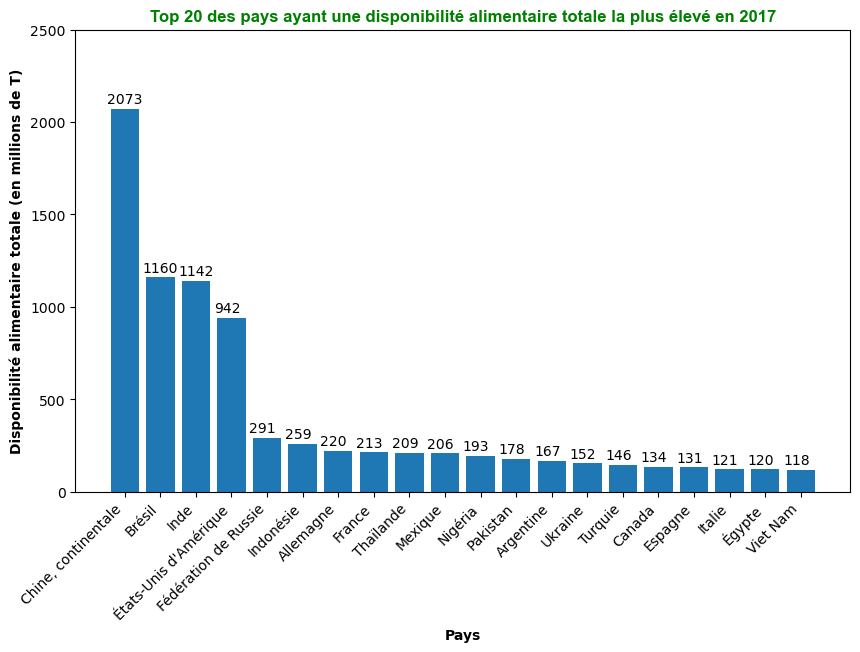

In [172]:
# Les 20 pays ayant les stock d'aliments les plus élevé en 2017 

data = dispo_alimentaire.sort_values("dispo_totale", ascending=False).head(20)

plt.figure(figsize=(10,6))
plt.bar(height=data["dispo_totale"], x=data["zone"])

plt.ylim(0, 2500) # Pour préciser l'étendu des valeurs de l'axes des ordonnées

plt.title("Top 20 des pays ayant une disponibilité alimentaire totale la plus élevé en 2017",
          color="green", fontweight="bold", fontname="Arial", fontsize=12)
plt.xlabel("Pays", fontweight ="bold")
plt.ylabel("Disponibilité alimentaire totale (en millions de T)", fontweight ="bold")
plt.xticks(rotation=45, ha='right')  # ha='right' = alignement à droite

# Afficher les valeurs associées à chaque niveau 

val_niv = data["dispo_totale"].tolist()
for i in range(20):
    plt.text(i-0.5, val_niv[i]+30, round(val_niv[i]))
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> b) - Distribution de l'utilisation de la dispobinilité alimentaire</h4>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h5 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> i - Distribution au niveau mondiale</h5>
</div>

In [176]:
# Repartition de la disponibilité alimentaire au niveau mondiale

categorie_usage = ["aliments_animaux", "nourriture", "pertes", "autres_ut", "semences", "traitement"]
dispo_al_usage = dispo_alimentaire[["zone", "dispo_int", "aliments_animaux", "nourriture", "pertes", "autres_ut", "semences", "traitement"]]

In [178]:
dispo_al_usage_mondiale = dispo_al_usage[categorie_usage].sum()

In [180]:
data = dispo_al_usage_mondiale.reset_index()

(-1.0999999699284, 1.099999998568019, -1.0999999693386537, 1.099999827619138)

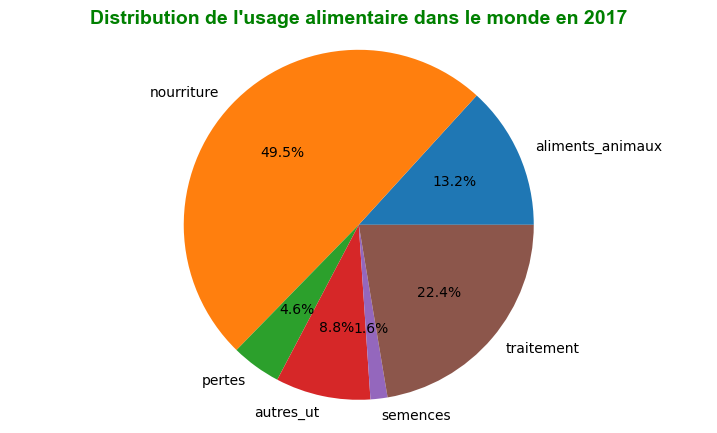

In [182]:
plt.figure(figsize=(9, 5))
plt.pie(x=data[0], labels=data['index'], autopct='%.1f%%')
plt.title("Distribution de l'usage alimentaire dans le monde en 2017", color="green", fontweight="bold", fontname="Arial", fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

<div style="border: 1px solid RGB(0,150,250);" >
<h5 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> i - Distribution au niveau de chaque pays</h5>
</div>

In [185]:
# Calcul de la proportion de la disponibilité intérieure allouée à chaque usage.

dispo_al_usage_propor = dispo_al_usage[["zone", "dispo_int"]].copy()


# Création des variables qui indique la proportion de la disponbilité intérieure allouée à chaque usage
for categorie in  categorie_usage:
    dispo_al_usage_propor[categorie] = round((dispo_al_usage[categorie] / dispo_al_usage["dispo_int"]) * 100, 2)


# affichage de la table

dispo_al_usage_propor.head()

,zone,dispo_int,aliments_animaux,nourriture,pertes,autres_ut,semences,traitement
0,Afghanistan,13.515,5.68,79.43,8.40,3.07,2.92,0.47
1,Afrique du Sud,61.256,8.67,48.67,3.58,1.43,0.41,37.25
2,Albanie,4.758,13.87,73.06,5.80,3.66,1.16,2.37
3,Algérie,42.630,10.21,74.43,8.80,4.00,1.05,1.49
4,Allemagne,162.275,18.62,48.83,2.33,4.75,0.96,24.55


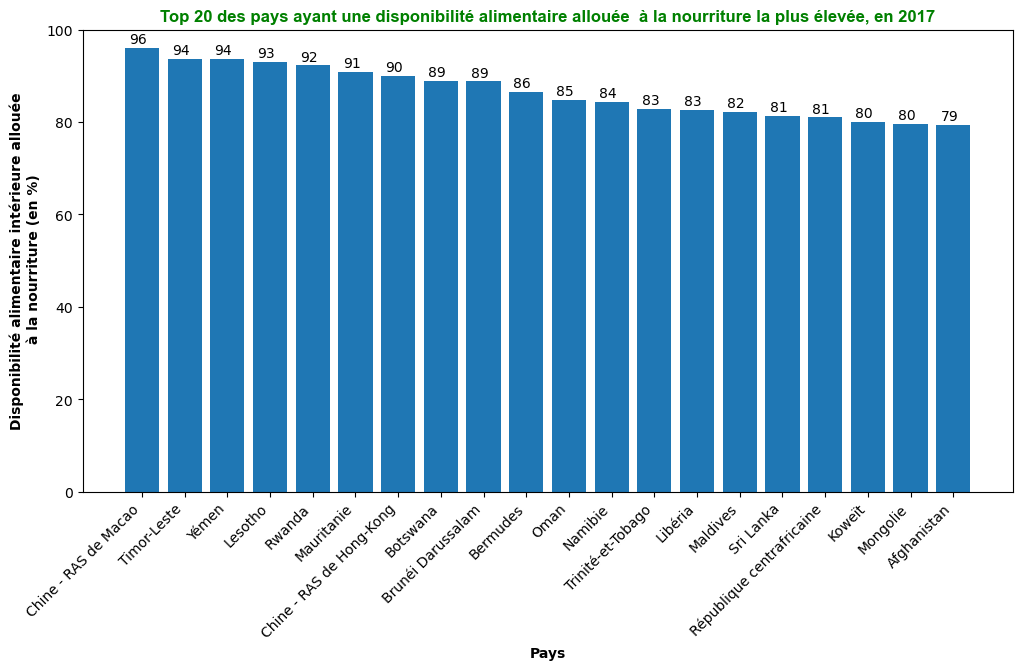

In [187]:
# Affichage du 10 des pays qui conncentre le plus de la disponibilité alimetaire pour la nourriture

plot_countries_by_level_indicator(data_frame=dispo_al_usage_propor, 
                                          column_name="nourriture", 
                                          n_countries=20,
                                          y_axis_limits=100,
                                          order="head",
                                          ylabel= "Disponibilité alimentaire intérieure allouée\n à la nourriture (en %)",
                                          title="Top 20 des pays ayant une disponibilité alimentaire allouée  à la nourriture la plus élevée, en 2017")

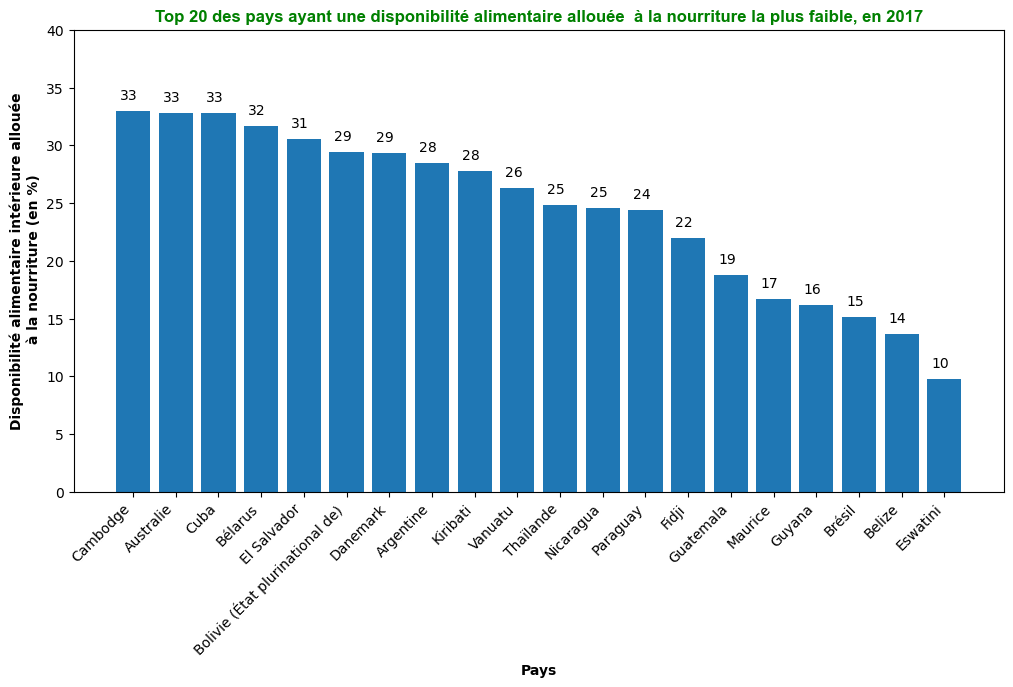

In [188]:
# Pays qui allouent le moins à la nourriture
plot_countries_by_level_indicator(data_frame=dispo_al_usage_propor, 
                                          column_name="nourriture", 
                                          n_countries=20,
                                          y_axis_limits=40,
                                          order="tail",
                                          ylabel= "Disponibilité alimentaire intérieure allouée\n à la nourriture (en %)",
                                          title="Top 20 des pays ayant une disponibilité alimentaire allouée  à la nourriture la plus faible, en 2017")

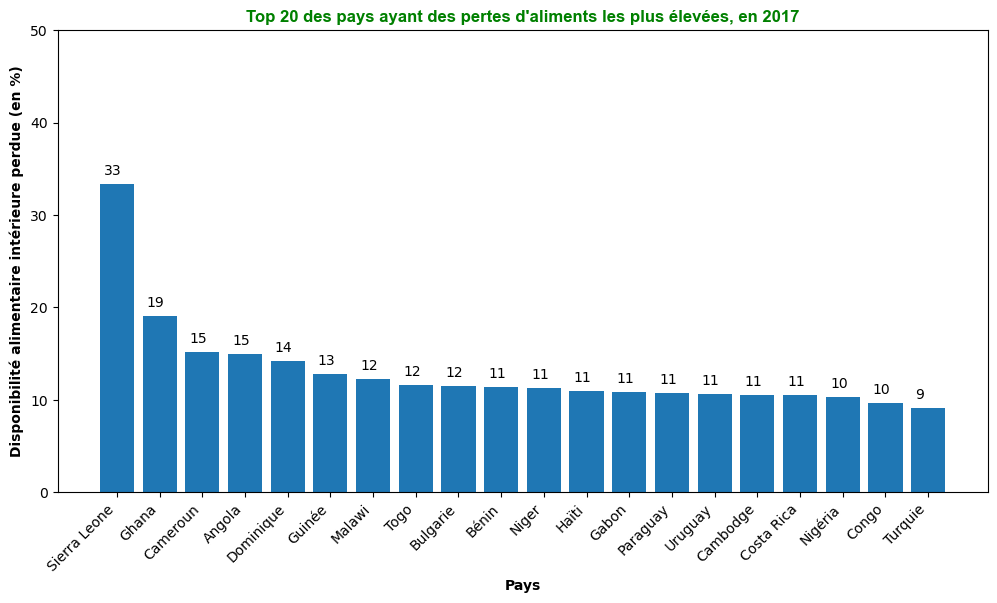

In [191]:
# Pays ayant les les pertes les plus élevées

plot_countries_by_level_indicator(data_frame=dispo_al_usage_propor, 
                                          column_name="pertes", 
                                          n_countries=20,
                                          y_axis_limits=50,
                                          order="head",
                                          ylabel= "Disponibilité alimentaire intérieure perdue (en %)",
                                          title="Top 20 des pays ayant des pertes d'aliments les plus élevées, en 2017")

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> 2.5 - Analyse de l'aide alimentaire</h3>
</div>

In [194]:
# Chargement des tables 

# On analyse l'évolution de l'aide sur la période 2013-2017
# et donc les données sur 2017 sont supprimées

df_aide_alim = pd.read_csv("df_aide_alimentaire.csv")
df_aide_alim = df_aide_alim.loc[df_aide_alim["année"] != 2017, :]


# Calcul du total d'aide alimentaire par pays depuis sur la période 2013-2016
df_aide_alim_pays = df_aide_alim.groupby("zone")["quantité"].sum().reset_index()


# Transformation des quantités d'aide en milliers de tonnes pour faciliter la lisibilité des graphiques
df_aide_alim_pays["quantité(en milliers T)"] = round((df_aide_alim_pays["quantité"] / 1_000), 1)

df_aide_alim_pays.sort_values("quantité(en milliers T)", ascending=False).head()

,zone,quantité,quantité(en milliers T)
51,République arabe syrienne,1858943,1858.9
75,Éthiopie,1381294,1381.3
70,Yémen,1206484,1206.5
61,Soudan du Sud,695248,695.2
60,Soudan,669784,669.8


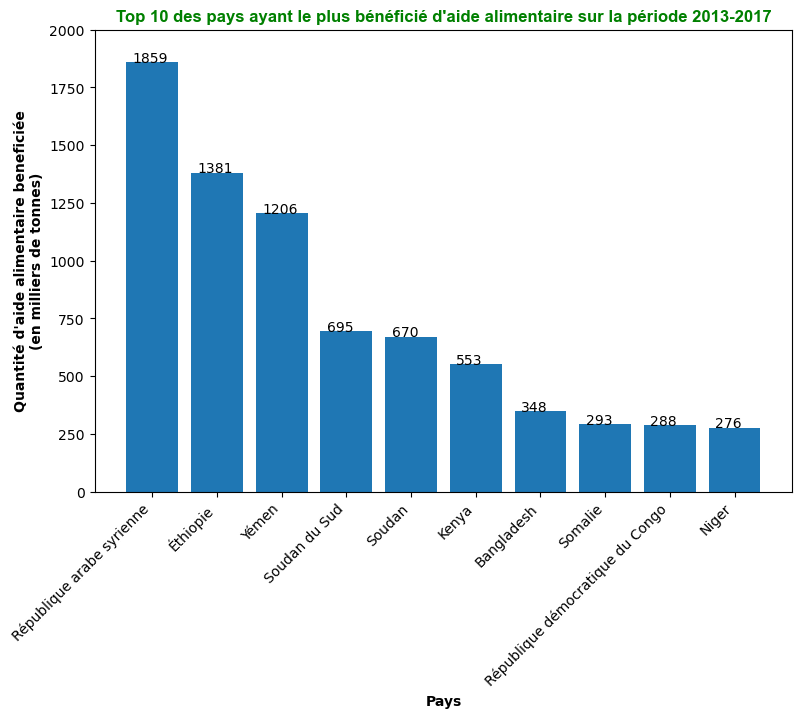

In [196]:
# Affichage des 10 pays qui ont beneficié le plus d'aide alimentaire depuis 2013


plot_countries_by_level_indicator(data_frame=df_aide_alim_pays, 
                                          column_name="quantité(en milliers T)", 
                                          n_countries=10,
                                          y_axis_limits=2000,
                                          fig_dimension=(9, 6),
                                          order="head",
                                          ylabel= "Quantité d'aide alimentaire beneficiée\n(en milliers de tonnes)",
                                          title="Top 10 des pays ayant le plus bénéficié d'aide alimentaire sur la période 2013-2017")

In [198]:
df_aide_alim

,zone,année,produit,quantité
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504
...,...,...,...,...
1470,Zimbabwe,2015,Mélanges et préparations,96
1471,Zimbabwe,2013,Non-céréales,5022
1472,Zimbabwe,2014,Non-céréales,2310
1473,Zimbabwe,2015,Non-céréales,306


In [200]:

# Calcul du total d'aide alimentaire par pays par année
df_aide_alim_pays_annee = df_aide_alim.groupby(["zone", "année"])["quantité"].sum().reset_index()



# Liste des 5 pays qui ont le plus beneficié d'aide
liste_top5_aide = df_aide_alim_pays.sort_values("quantité(en milliers T)", ascending=False).head()["zone"].tolist()


# Création d'un dataframe des 5 pays qui ont le plus beneficié de l'aide
df_aide_alim_top_5 = df_aide_alim_pays_annee.loc[df_aide_alim_pays_annee["zone"].isin(liste_top5_aide), :]

# Transformation des quantités d'aide alimentaire des Tonnes en milliers de tonnes
df_aide_alim_top_5["quantité(en milliers T)"] = round((df_aide_alim_top_5["quantité"] / 1_000), 1)


C:\Users\Fujitsu\AppData\Local\Temp\ipykernel_15868\3876394802.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aide_alim_top_5["quantité(en milliers T)"] = round((df_aide_alim_top_5["quantité"] / 1_000), 1)


In [202]:


df_aide_alim_top_5.head()

,zone,année,quantité,quantité(en milliers T)
161,République arabe syrienne,2013,563566,563.6
162,République arabe syrienne,2014,651870,651.9
163,République arabe syrienne,2015,524949,524.9
164,République arabe syrienne,2016,118558,118.6
189,Soudan,2013,330230,330.2


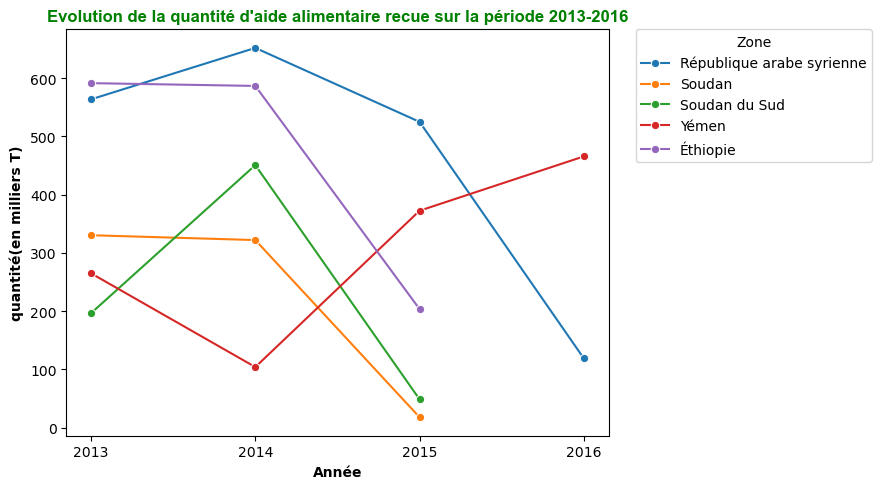

In [204]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exemple de DataFrame déjà formaté
# sns.lineplot(data=df, x="année", y="quantité", hue="zone")


# Affichage de l'aide ailementaire des 5 pays par années
plt.figure(figsize=(9, 5))
sns.lineplot(data=df_aide_alim_top_5, x="année", y="quantité(en milliers T)", hue="zone", marker='o')

# Légende en dehors à droite
plt.legend(title='Zone', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Titre et labels
plt.title("Evolution de la quantité d'aide alimentaire recue sur la période 2013-2016",
          color="green", fontweight="bold", fontname="Arial", fontsize=12)
plt.xlabel("Année", fontweight="bold")
plt.ylabel("quantité(en milliers T)", fontweight="bold")
plt.xticks([2013, 2014, 2015, 2016])

plt.tight_layout()  # Pour éviter que la légende dépasse de la figure
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> 2.6 - Utilisation des céréales</h3>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> a) Proportion des céréales</h4>
</div>

In [208]:
# Chargement de la table disponibilité alimentaire
dispo_al = pd.read_csv("df_disponibilite_alimentaire.csv")


# Liste de tous les produits
produits = dispo_al["produit"].unique().tolist()

# Listes des produits d'origine animale
produits_animale = dispo_al.loc[dispo_al["origine"] == "animale", "produit"].unique().tolist()


# Liste des produits d'origine végétale 
produits_vegetale = dispo_al.loc[dispo_al["origine"] == "vegetale", "produit"].unique().tolist()

# Listes des céréales considérées
cereales = ['Blé', 'Maïs', 'Millet', 'Orge', 'Riz (Eq Blanchi)', 'Avoine', 'Seigle', 'Sorgho', 'Céréales, Autres']


# Création d'une variable qui indique si le produit est une céréale ou pas
dispo_alimentaire = dispo_al.copy()

dispo_alimentaire["type_produit"] = "autre produit"
dispo_alimentaire.loc[dispo_alimentaire["produit"].isin(cereales), "type_produit"] = "céréale"

# Affichage du dataset
dispo_alimentaire.head()

,zone,produit,origine,aliments_animaux,autres_ut,dispo_alim_kcal,dispo_alim_kg,dispo_matiere_gr,dispo_proteine,dispo_int,exportations,importations,nourriture,pertes,production,semences,traitement,variation_stock,type_produit
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,0.053,0.000,0.000,0.053,0.000,0.053,0.0,0.0,0.0,autre produit
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,0.041,0.002,0.040,0.039,0.002,0.003,0.0,0.0,0.0,autre produit
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,0.002,0.000,0.002,0.002,0.000,0.000,0.0,0.0,0.0,autre produit
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,autre produit
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,0.082,0.000,0.082,0.082,0.000,0.000,0.0,0.0,0.0,autre produit


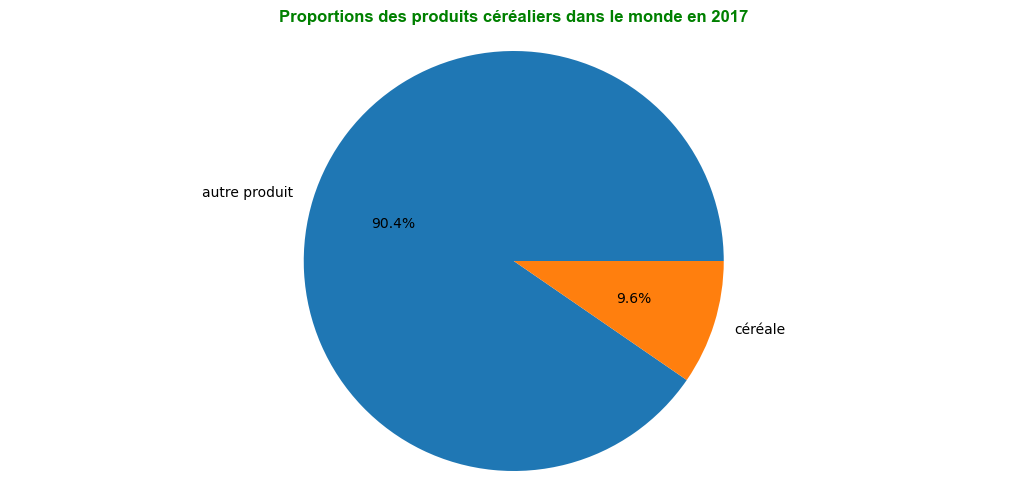

In [210]:
# Affichage de la proportion des produits céréaliers

plot_pie_chart(
    data=dispo_alimentaire,
    category_column="type_produit",
    title="Proportions des produits céréaliers dans le monde en 2017"
)

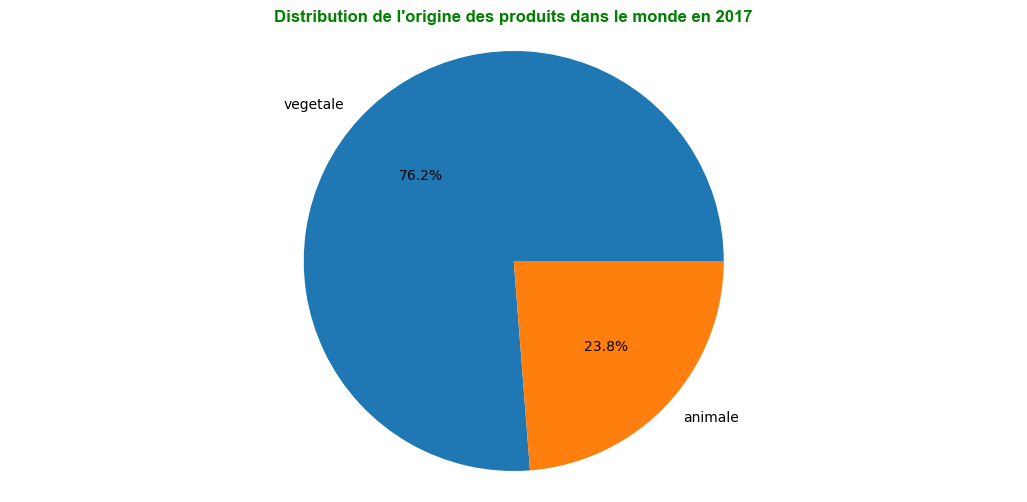

In [212]:
# Affichage de la distribution de l'origine des produites

plot_pie_chart(
    data=dispo_alimentaire,
    category_column="origine",
    title="Distribution de l'origine des produits dans le monde en 2017"
)

<div style="border: 1px solid RGB(0,150,250);" >
<h4 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> b) Distribution de l'utilisation des céréales</h4>
</div>

In [215]:
# Calcul de la quantité de céréales allouée à chaque type d'usage.
df_usage = dispo_alimentaire.groupby("type_produit")[["aliments_animaux", "nourriture", "traitement", "semences", "pertes", "autres_ut"]].sum().reset_index()
df_usage

,type_produit,aliments_animaux,nourriture,traitement,semences,pertes,autres_ut
0,autre produit,430.710,3847.248,2110.098,86.143,346.578,630.236
1,céréale,873.535,1029.010,94.589,68.538,107.120,234.787


(-1.099993639802822,
 1.0999996971334678,
 -1.0999900802004643,
 1.099997760905171)

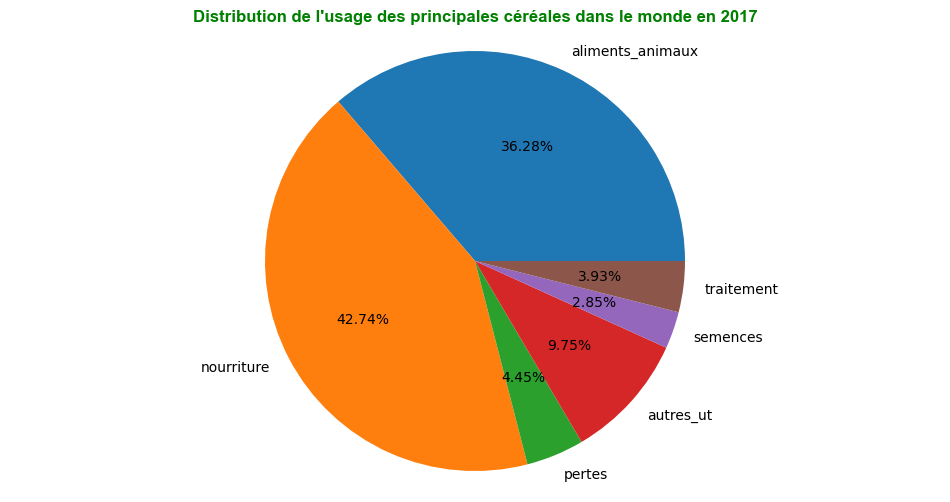

In [217]:
# Création d'une table sur l'usage des céréales
data_ = {
    'aliments_animaux': 873.535,
    'nourriture': 1029.010,
    'pertes': 107.120,
    'autres_ut': 234.787,
    'semences': 68.538,
    'traitement': 94.589
}

# Transformation en DataFrame
data_cereales = pd.DataFrame(list(data_.items()), columns=['Utilisation', 'Quantité'])

# Affichage du graphique 
plt.figure(figsize=(12,6))
plt.pie(x=data_cereales['Quantité'], labels=data_cereales['Utilisation'], autopct='%.2f%%')
plt.title("Distribution de l'usage des principales céréales dans le monde en 2017", color="green", fontweight="bold", fontname="Arial", fontsize=12)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); "> 2.7 - Exemple de la Thailande pour le manioc</h3>
</div>

In [220]:
# Création des dataframe uniquement pour la thailande

# Importation de la table sur la sous nutrition créé à la section 2.2 b
df_sous_nutrition = pd.read_csv("df_sous_nutrition_2.csv")
sous_nutrit_thai = df_sous_nutrition.loc[df_sous_nutrition["zone"] == "Thaïlande", :]

# table sur la disponibilité alimentaire en thailande 
dispo_alim_thai = df_dispo_al.loc[df_dispo_al["zone"] == "Thaïlande", ["zone", "produit", "dispo_int", "exportations", "importations", "production"]]


In [222]:
sous_nutrit_thai.head()

,zone,periode,année,pop_sous_alim,population,prop_pop_sous_al
925,Thaïlande,2012-2014,2013,6200000.0,68144518.0,9.10
926,Thaïlande,2013-2015,2014,6000000.0,68438746.0,8.77
927,Thaïlande,2014-2016,2015,5900000.0,68714511.0,8.59
928,Thaïlande,2015-2017,2016,6000000.0,68971308.0,8.70
929,Thaïlande,2016-2018,2017,6200000.0,69209810.0,8.96


([<matplotlib.axis.XTick at 0x1c231141b50>,
 [Text(2013, 0, '2013'),
  Text(2014, 0, '2014'),
  Text(2015, 0, '2015'),
  Text(2016, 0, '2016'),
  Text(2017, 0, '2017')])

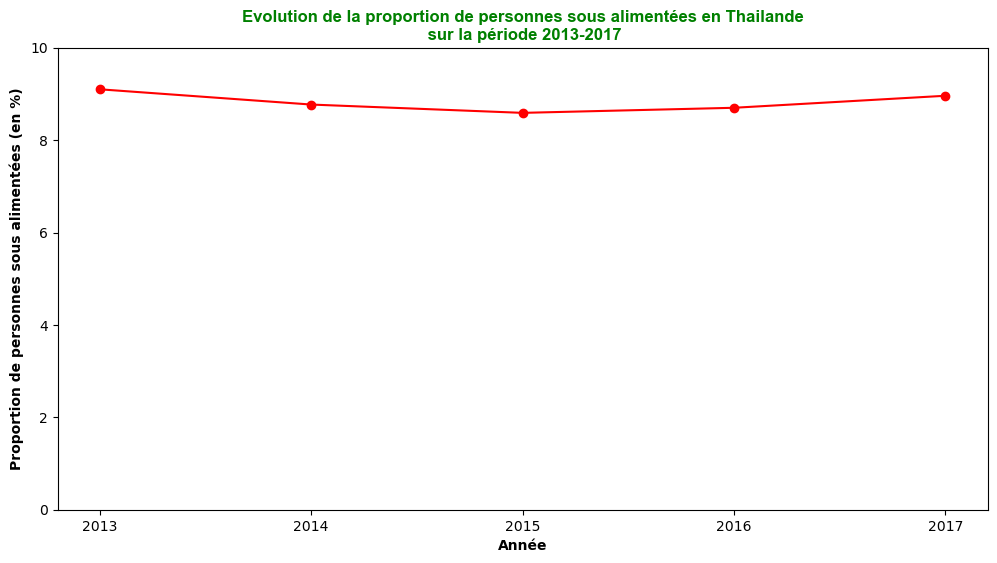

In [224]:
# Evolution de la proportion des personnes sous alimentées en thaillande

plt.figure(figsize=(12,6))
plt.plot(sous_nutrit_thai["année"], sous_nutrit_thai["prop_pop_sous_al"], marker='o', color='red')
plt.title("Evolution de la proportion de personnes sous alimentées en Thailande\n sur la période 2013-2017",
          color="green", fontweight="bold", fontname="Arial", fontsize=12)
plt.xlabel("Année", fontweight ="bold")
plt.ylabel("Proportion de personnes sous alimentées (en %)", fontweight ="bold")
plt.ylim(0, 10),
plt.xticks([2013, 2014, 2015, 2016, 2017])




In [226]:
# Création de la variable qui indique si le produit est le manioc ou pas 

dispo_alim_thai["type_produit"] = "Manioc"
dispo_alim_thai.loc[dispo_alim_thai["produit"] != "Manioc",  "type_produit"] = "Autres produits"

(-1.0999998387551844,
 1.0999999923216754,
 -1.0999999832492628,
 1.0999998969288187)

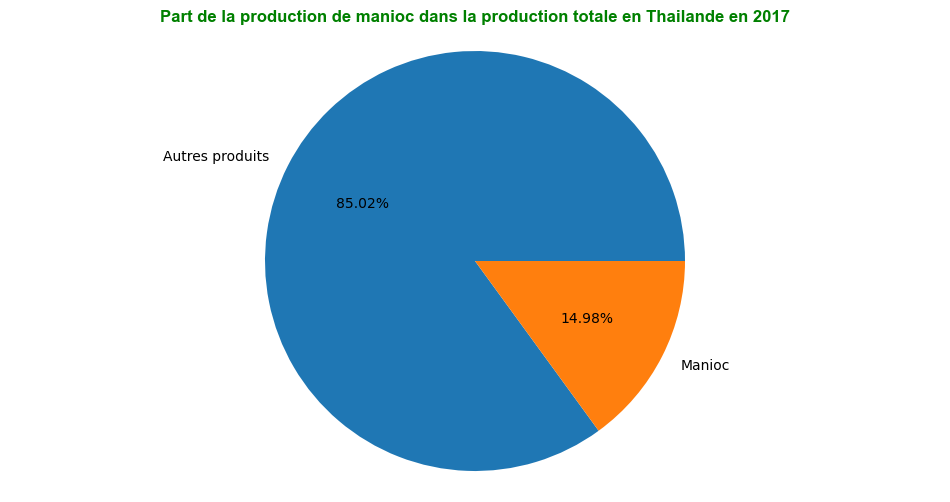

In [228]:
# Proportion du manioc dans la production 

df = dispo_alim_thai.groupby("type_produit")["production"].sum().reset_index()

plt.figure(figsize=(12,6))
plt.pie(x=df['production'], labels=df['type_produit'], autopct='%.2f%%')
plt.title("Part de la production de manioc dans la production totale en Thailande en 2017",
          color="green", fontweight="bold", fontname="Arial", fontsize=12)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle


In [230]:
dispo_alim_thai

,zone,produit,dispo_int,exportations,importations,production,type_produit
13759,Thaïlande,Abats Comestible,0.074,0.005,0.033,0.045,Autres produits
13760,Thaïlande,"Agrumes, Autres",0.008,0.006,0.002,0.012,Autres produits
13761,Thaïlande,"Alcool, non Comestible",0.358,0.110,0.021,0.447,Autres produits
13762,Thaïlande,Aliments pour enfants,0.012,0.007,0.019,0.000,Autres produits
13763,Thaïlande,Ananas,0.782,1.449,0.009,2.209,Autres produits
...,...,...,...,...,...,...,...
13849,Thaïlande,Viande de Suides,0.871,0.022,0.001,0.891,Autres produits
13850,Thaïlande,Viande de Volailles,0.945,0.536,0.011,1.470,Autres produits
13851,Thaïlande,"Viande, Autre",-0.092,0.096,0.004,0.000,Autres produits
13852,Thaïlande,Vin,0.008,0.008,0.016,0.000,Autres produits


(-1.099999999999999,
 1.0999999999999999,
 -1.099999999999999,
 1.0999999999999999)

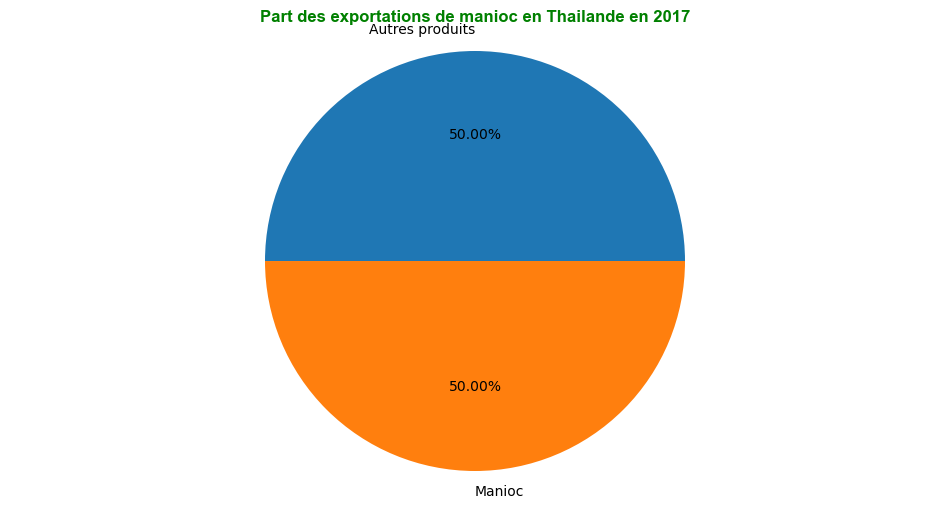

In [232]:
# Proportion du manioc dans les exportations

df2 = dispo_alim_thai.groupby("type_produit")["exportations"].sum().reset_index()

plt.figure(figsize=(12,6))
plt.pie(x=df2['exportations'], labels=df2['type_produit'], autopct='%.2f%%')
plt.title("Part des exportations de manioc en Thailande en 2017",
          color="green", fontweight="bold", fontname="Arial", fontsize=12)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle


In [234]:
# Table sur l'usage du manioc en Thailande

dispo_usage_manioc_thai = df_dispo_al.loc[(df_dispo_al["zone"] == "Thaïlande") & (df_dispo_al["produit"] == "Manioc"), 
                                ["zone", "produit", "dispo_int", "aliments_animaux", "nourriture", "pertes", "autres_ut",
                                 "semences", "traitement", "importations", 	"production", "variation_stock"]]
categorie_usage = ["aliments_animaux", "nourriture", "pertes", "autres_ut", "semences", "traitement"]  

In [236]:
# Les différentes usage du manioc en thailande en 2017

dispo_usage_manioc_thai

,zone,produit,dispo_int,aliments_animaux,nourriture,pertes,autres_ut,semences,traitement,importations,production,variation_stock
13809,Thaïlande,Manioc,6.264,1.8,0.871,1.511,2.081,0.0,0.0,1.25,30.228,0.0


(-1.099999743180557,
 1.0999999877705027,
 -1.0999996268605585,
 1.0999999202796782)

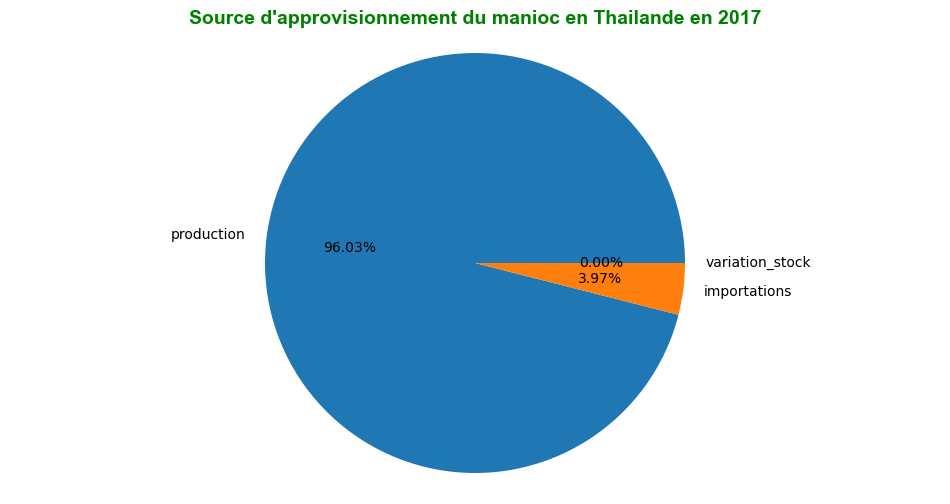

In [238]:
data2 = {
    'production': 30.228,
    'importations': 1.25,
    'variation_stock': 0.00
}

# Transformation en DataFrame
thai_approv_manioc = pd.DataFrame(list(data2.items()), columns=['provenance', 'Quantité'])



plt.figure(figsize=(12,6))
plt.pie(x=thai_approv_manioc['Quantité'], labels=thai_approv_manioc['provenance'], autopct='%.2f%%')
plt.title("Source d'approvisionnement du manioc en Thailande en 2017",
          color="green", fontweight="bold", fontname="Arial", fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

(-1.099978701719947, 1.099998985796188, -1.099999948125126, 1.0999989135998751)

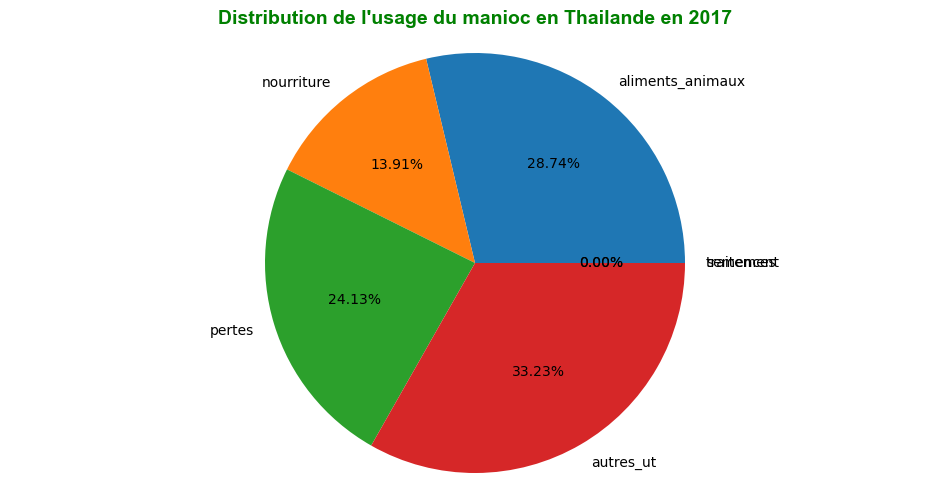

In [240]:
data3 = {
    'aliments_animaux': 1.8,
    'nourriture': 0.871,
    'pertes': 1.511,
    'autres_ut': 2.081,
    'semences': 0.0,
    'traitement': 0.0
}

# Transformation en DataFrame
thai_usage_manioc = pd.DataFrame(list(data3.items()), columns=['Utilisation', 'Quantité'])


plt.figure(figsize=(12,6))
plt.pie(x=thai_usage_manioc['Quantité'], labels=thai_usage_manioc['Utilisation'], autopct='%.2f%%')
plt.title("Distribution de l'usage du manioc en Thailande en 2017",
          color="green", fontweight="bold", fontname="Arial", fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

In [242]:
# Exportation et production de manioc en thaillande 

dispo_alim_thai.loc[dispo_alim_thai["produit"] == "Manioc",  ["zone", "exportations", "production"]]


,zone,exportations,production
13809,Thaïlande,25.214,30.228
